In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from pathlib import Path

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy

from algos import BING_BONG, FFPR2, PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize, curve_fit

from scipy.interpolate import RegularGridInterpolator

from scipy.spatial import ConvexHull

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
# from algos import pdpr, OPD, ADPR
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

In [2]:
!nvidia-smi

Wed Aug 19 22:35:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   29C    P0             42W /  300W |      14MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

sys = telescope(config=config, optic_opd_data=optic_opd_data)

In [4]:
amp = sys.pupil

x, y = make_xy_grid(shape=amp.shape, diameter=2 / 0.98)
r_norm, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(1, 50)]
zernikes = list(zernike_nm_seq(nms, r_norm, t, norm=True))

## new

### process data

In [5]:
fpath = '/npool/nvme/derbyk/20260616_mfpr_mc/'
fname = '/mis_med_srcmag_17_nsrc_9_randf_true'

data = utils.load_pickle(fpath + fname + '.pkl')

In [19]:
fpath = '/npool/nvme/derbyk/20260616_mfpr_mc/'
fnamess = [[f'mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true' for n in [15, 16, 17, 18, 19]] for m in [9]]

for fnames in fnamess:    
    for fname in fnames:
        print('LOAD ' + fname)

        data = utils.load_pickle(fpath + fname + '.pkl')

        newpath = Path(fpath + fname)
        newpath.mkdir(parents=True, exist_ok=True)

        net_divs = np.zeros(len(data))
        areas = np.zeros(len(data))

        for i, case in enumerate(data):
            print('ANALYZING CASE ' + str(i + 1), end='\r')

            # fields = _np.array(data[case]['FIELDS'])
            # hull = ConvexHull(fields)
            # areas[i] = hull.area

            wfes_nom = data[case]['WFE_NOMINAL']
            diffs = []
            for n in range(len(wfes_nom)):
                for m in range(len(wfes_nom)):
                    if m > n:
                        diffs.append(lstsq(zernikes, wfes_nom[n] - wfes_nom[m])[3:11])
            rss_diffs = np.sqrt(np.sum(np.array(diffs) ** 2, axis=0))
            net_divs[i] = np.sqrt(np.sum(rss_diffs ** 2))
        
        fits.writeto(fpath + fname + '/net_divs.fits', data=net_divs.get(), overwrite=True)
        # fits.writeto(fpath + fname + '/areas.fits', data=areas.get(), overwrite=True)

LOAD mis_med_srcmag_15_nsrc_9_randf_true
LOAD mis_med_srcmag_16_nsrc_9_randf_true
LOAD mis_med_srcmag_17_nsrc_9_randf_true
LOAD mis_med_srcmag_18_nsrc_9_randf_true
LOAD mis_med_srcmag_19_nsrc_9_randf_true


In [13]:
fpath = '/npool/nvme/derbyk/20260616_mfpr_mc/'
fnamess = [[f'mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

for fnames in fnamess:  
    for fname in fnames:
        print('LOAD ' + fname)

        data = utils.load_pickle(fpath + fname + '.pkl')

        newpath = Path(fpath + fname)
        newpath.mkdir(parents=True, exist_ok=True)

        mean_snr = np.zeros(len(data))
        mean_res_all = np.zeros(len(data))
        mean_res_low = np.zeros(len(data))
        mean_err = np.zeros(len(data))
        coeffs_tru = np.zeros((len(data), 8))
        coeffs_est = np.zeros((len(data), 8))
        coeffs_diff = np.zeros((len(data), 8))

        for i, case in enumerate(data):
            print('ANALYZING CASE ' + str(i + 1), end='\r')

            # mean snr per case
            snrs = data[case]['SNR_PER_FIELD']
            mean_snr[i] = np.mean(np.array(snrs))

            # mean rms residuals per case
            opds_est = data[case]['WFE_ESTIMATE']
            opds_tru = data[case]['WFE_TRUTH']

            res_all = []
            res_low = []
            err = []
            ct = np.zeros((len(opds_est), 8))
            ce = np.zeros((len(opds_est), 8))
            cd = np.zeros((len(opds_est), 8))

            for j, (opd_est, opd_tru) in enumerate(zip(copy.deepcopy(opds_est), copy.deepcopy(opds_tru))):

                # total residual
                opd_diff = opd_est - opd_tru
                opd_diff[~amp] = np.nan
                opd_diff -= np.nanmean(opd_diff)
                res_all.append(np.sqrt(np.nanmean(opd_diff ** 2)))

                # low order residual
                opd_est[~amp] = np.nan
                opd_tru[~amp] = np.nan
                opd_est -= np.nanmean(opd_est)
                opd_tru -= np.nanmean(opd_tru)
                c_est = lstsq(zernikes, opd_est)[3:11]
                c_tru = lstsq(zernikes, opd_tru)[3:11]
                ce[j, :] = c_est
                ct[j, :] = c_tru
                cd[j, :] = c_est - c_tru

                oe = sum_of_2d_modes(np.array(zernikes[3:11]), c_est) * amp
                ot = sum_of_2d_modes(np.array(zernikes[3:11]), c_tru) * amp
                res_low.append(np.sqrt(np.mean((oe - ot) ** 2)))

                # ground truth error
                err.append(np.sqrt(np.nanmean(opd_tru ** 2)))

            mean_res_all[i] = np.mean(np.array(res_all))
            mean_res_low[i] = np.mean(np.array(res_low))
            mean_err[i] = np.mean(np.array(err))
            coeffs_est[i, :] = np.mean(ce, axis=0)
            coeffs_tru[i, :] = np.mean(ct, axis=0)
            coeffs_diff[i, :] = np.sqrt(np.mean(cd ** 2, axis=0))

        fits.writeto(fpath + fname + '/mean_snr.fits', data=mean_snr.get(), overwrite=True)
        fits.writeto(fpath + fname + '/mean_residual_all.fits', data=mean_res_all.get(), overwrite=True)
        fits.writeto(fpath + fname + '/mean_residual_low.fits', data=mean_res_low.get(), overwrite=True)
        fits.writeto(fpath + fname + '/mean_wfe.fits', data=mean_err.get(), overwrite=True)
        fits.writeto(fpath + fname + '/coeffs_tru.fits', data=coeffs_tru.get(), overwrite=True)
        fits.writeto(fpath + fname + '/coeffs_est.fits', data=coeffs_est.get(), overwrite=True)
        fits.writeto(fpath + fname + '/coeffs_diff.fits', data=coeffs_diff.get(), overwrite=True)

LOAD mis_med_srcmag_15_nsrc_3_randf_true
LOAD mis_med_srcmag_16_nsrc_3_randf_true
LOAD mis_med_srcmag_17_nsrc_3_randf_true
LOAD mis_med_srcmag_18_nsrc_3_randf_true
LOAD mis_med_srcmag_19_nsrc_3_randf_true
LOAD mis_med_srcmag_15_nsrc_5_randf_true
LOAD mis_med_srcmag_16_nsrc_5_randf_true
LOAD mis_med_srcmag_17_nsrc_5_randf_true
LOAD mis_med_srcmag_18_nsrc_5_randf_true
LOAD mis_med_srcmag_19_nsrc_5_randf_true
LOAD mis_med_srcmag_15_nsrc_7_randf_true
LOAD mis_med_srcmag_16_nsrc_7_randf_true
LOAD mis_med_srcmag_17_nsrc_7_randf_true
LOAD mis_med_srcmag_18_nsrc_7_randf_true
LOAD mis_med_srcmag_19_nsrc_7_randf_true
LOAD mis_med_srcmag_15_nsrc_9_randf_true
LOAD mis_med_srcmag_16_nsrc_9_randf_true
LOAD mis_med_srcmag_17_nsrc_9_randf_true
LOAD mis_med_srcmag_18_nsrc_9_randf_true
LOAD mis_med_srcmag_19_nsrc_9_randf_true


### residual vs snr

Text(0, 0.5, 'Mean RMS\nLow-Order Residual (nm)')

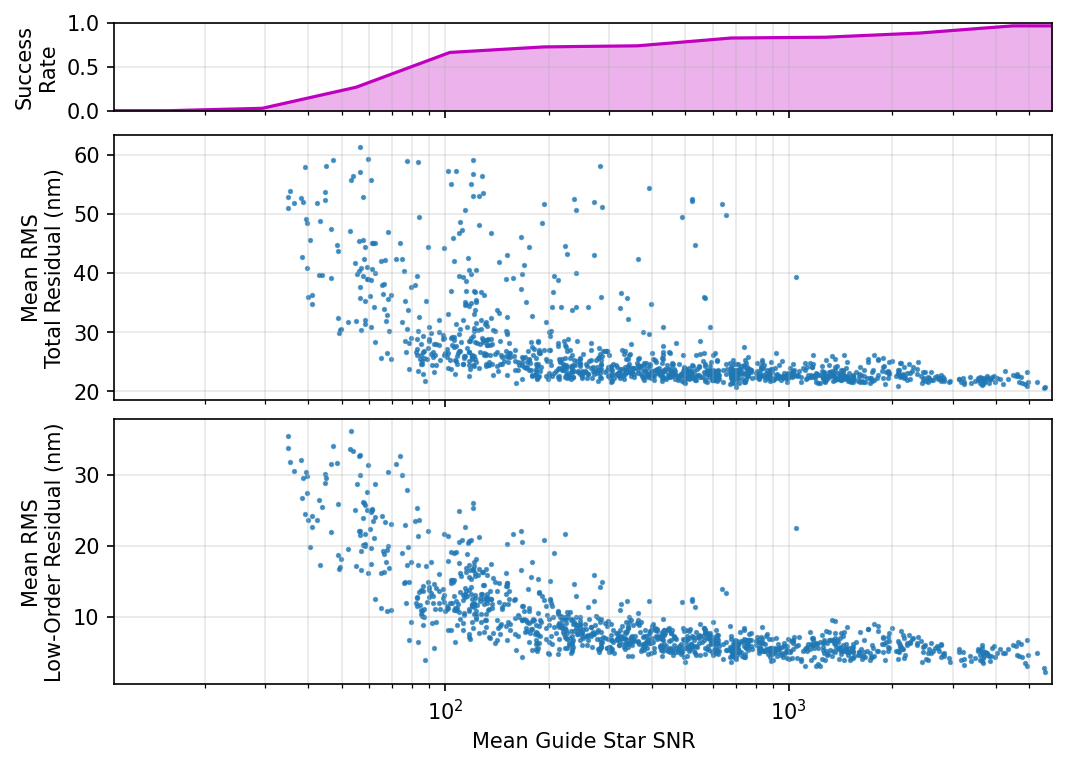

In [12]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

x = _np.empty(0)
y1 = _np.empty(0)
y2 = _np.empty(0)

for fpaths in fpathss:
    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        y1 = _np.concatenate((y1, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        y2 = _np.concatenate((y2, fits.getdata(fpath + 'mean_residual_low.fits')), axis=0)

xmin = x.min()
xmax = x.max() * 1.05

n_bins = 10
cutoffs = _np.logspace(_np.log10(xmin), _np.log10(xmax), n_bins + 1)

p = [0]
xp = [cutoffs[0]]

for i in range(n_bins):
    low = cutoffs[i]
    high = cutoffs[i + 1]
    inds = (x >= low) & (x <= high)
    good = y1[inds] < 62.5

    p.append(sum(good) / sum(inds))
    xp.append((low + high) / 2)

p.append(p[-1])
xp.append(cutoffs[-1])
p = _np.array(p)
xp = _np.array(xp)

fig, axs = plt.subplot_mosaic([['pdf'],
                               ['all_residual'],
                               ['low_residual']],
                               figsize=(7, 5), 
                               height_ratios=[1, 3, 3],
                               layout='constrained',
                               dpi=150)

ax = axs['pdf']
ax.semilogx(xp, p, c='m')
ax.fill_between(xp, p, alpha=0.3, color='m')
ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 1])
ax.grid(which='both', alpha=0.3)
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Success\nRate')

ax = axs['all_residual']
ax.scatter(x[y1 < 62.5], y1[y1 < 62.5], alpha=0.7, marker='.', s=10)
# ax.scatter(x[y1 > 62.5], _np.ones(sum(y1 > 62.5)) * 62, alpha=0.7, c='r', marker='x', label='Failed Case')
ax.set_xscale('log')
ax.grid(which='both', alpha=0.3)
ax.set_xlim([xmin, xmax])
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Mean RMS\nTotal Residual (nm)')

ax = axs['low_residual']
ax.scatter(x[y1 < 62.5], y2[y1 < 62.5], alpha=0.7, marker='.', s=10)
# ax.scatter(x[y1 > 62.5], _np.ones(sum(y1 > 62.5)) * 62, alpha=0.7, c='r', marker='x', label='Failed Case')
ax.set_xscale('log')
ax.grid(which='both', alpha=0.3)
ax.set_xlim([xmin, xmax])
ax.set_xlabel('Mean Guide Star SNR')
ax.set_ylabel('Mean RMS\nLow-Order Residual (nm)')

### residual vs rms wfe

Text(0, 0.5, 'Mean RMS\nLow-Order Residual (nm)')

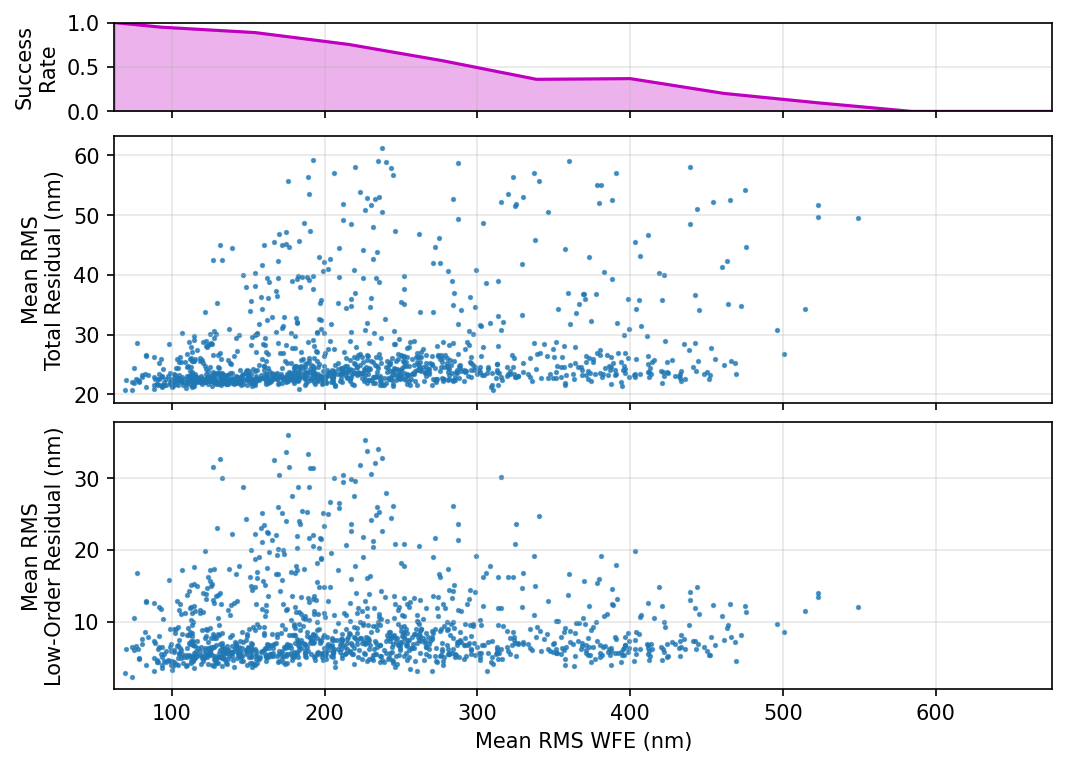

In [10]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

x = _np.empty(0)
y1 = _np.empty(0)
y2 = _np.empty(0)

for fpaths in fpathss:
    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'mean_wfe.fits')), axis=0)
        y1 = _np.concatenate((y1, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        y2 = _np.concatenate((y2, fits.getdata(fpath + 'mean_residual_low.fits')), axis=0)

xmin = x.min() * 0.9
xmax = x.max() * 1.05

n_bins = 10
cutoffs = _np.linspace(xmin, xmax, n_bins + 1)

p = [1]
xp = [cutoffs[0]]

for i in range(n_bins):
    low = cutoffs[i]
    high = cutoffs[i + 1]
    inds = (x >= low) & (x <= high)
    good = y1[inds] < 62.5

    p.append(sum(good) / sum(inds))
    xp.append((low + high) / 2)

p.append(p[-1])
xp.append(cutoffs[-1])
p = _np.array(p)
xp = _np.array(xp)

fig, axs = plt.subplot_mosaic([['pdf'],
                               ['all_residual'],
                               ['low_residual']],
                               figsize=(7, 5), 
                               height_ratios=[1, 3, 3],
                               layout='constrained',
                               dpi=150)

ax = axs['pdf']
ax.plot(xp, p, c='m')
ax.fill_between(xp, p, alpha=0.3, color='m')
ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 1])
ax.grid(which='both', alpha=0.3)
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Success\nRate')

ax = axs['all_residual']
ax.scatter(x[y1 < 62.5], y1[y1 < 62.5], alpha=0.7, marker='.', s=10)
# ax.scatter(x[y1 > 62.5], _np.ones(sum(y1 > 62.5)) * 62, alpha=0.7, c='r', marker='x', label='Failed Case')
# ax.set_xscale('log')
ax.grid(which='both', alpha=0.3)
ax.set_xlim([xmin, xmax])
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Mean RMS\nTotal Residual (nm)')

ax = axs['low_residual']
ax.scatter(x[y1 < 62.5], y2[y1 < 62.5], alpha=0.7, marker='.', s=10)
# ax.scatter(x[y1 > 62.5], _np.ones(sum(y1 > 62.5)) * 62, alpha=0.7, c='r', marker='x', label='Failed Case')
# ax.set_xscale('log')
ax.grid(which='both', alpha=0.3)
ax.set_xlim([xmin, xmax])
ax.set_xlabel('Mean RMS WFE (nm)')
ax.set_ylabel('Mean RMS\nLow-Order Residual (nm)')

### residual vs net diversity

Text(0, 0.5, 'Mean RMS\nLow-Order Residual (nm)')

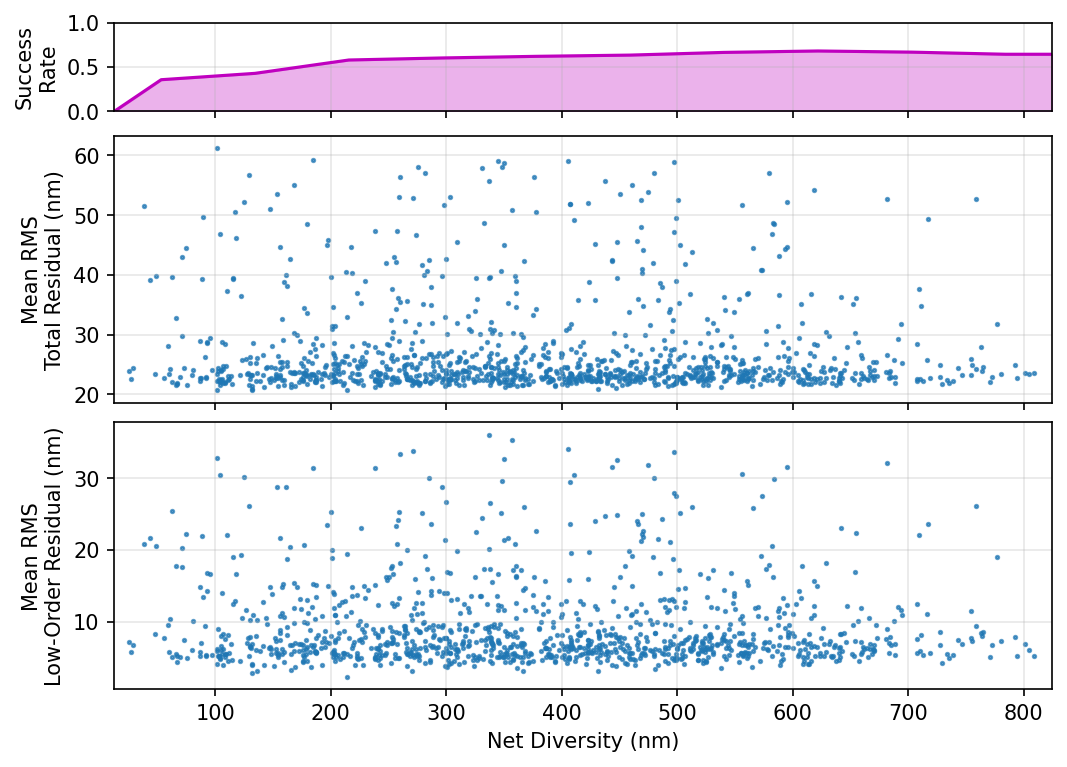

In [6]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

x = _np.empty(0)
y1 = _np.empty(0)
y2 = _np.empty(0)

for fpaths in fpathss:
    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'net_divs.fits')), axis=0)
        y1 = _np.concatenate((y1, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        y2 = _np.concatenate((y2, fits.getdata(fpath + 'mean_residual_low.fits')), axis=0)

xmin = x.min() * 0.5
xmax = 825

n_bins = 10
cutoffs = _np.linspace(xmin, xmax, n_bins + 1)

p = [0]
xp = [cutoffs[0]]

for i in range(n_bins):
    low = cutoffs[i]
    high = cutoffs[i + 1]
    inds = (x >= low) & (x <= high)
    good = y1[inds] < 62.5

    p.append(sum(good) / sum(inds))
    xp.append((low + high) / 2)

p.append(p[-1])
xp.append(cutoffs[-1])
p = _np.array(p)
xp = _np.array(xp)

fig, axs = plt.subplot_mosaic([['pdf'],
                               ['all_residual'],
                               ['low_residual']],
                               figsize=(7, 5), 
                               height_ratios=[1, 3, 3],
                               layout='constrained',
                               dpi=150)

ax = axs['pdf']
ax.plot(xp, p, c='m')
ax.fill_between(xp, p, alpha=0.3, color='m')
ax.set_xlim([xmin, xmax])
ax.set_ylim([0, 1])
ax.grid(which='both', alpha=0.3)
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Success\nRate')

ax = axs['all_residual']
ax.scatter(x[y1 < 62.5], y1[y1 < 62.5], alpha=0.7, marker='.', s=10)
# ax.scatter(x[y1 > 62.5], _np.ones(sum(y1 > 62.5)) * 62, alpha=0.7, c='r', marker='x', label='Failed Case')
ax.grid(which='both', alpha=0.3)
ax.set_xlim([xmin, xmax])
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Mean RMS\nTotal Residual (nm)')

ax = axs['low_residual']
ax.scatter(x[y1 < 62.5], y2[y1 < 62.5], alpha=0.7, marker='.', s=10)
# ax.scatter(x[y1 > 62.5], _np.ones(sum(y1 > 62.5)) * 62, alpha=0.7, c='r', marker='x', label='Failed Case')
ax.grid(which='both', alpha=0.3)
ax.set_xlim([xmin, xmax])
ax.set_xlabel('Net Diversity (nm)')
ax.set_ylabel('Mean RMS\nLow-Order Residual (nm)')

### residuals by zernike

In [51]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

est = _np.empty((0, 8))
tru = _np.empty((0, 8))
snr = _np.empty(0)
div = _np.empty(0)

for fpaths in fpathss:
    for fpath in fpaths:
        est = _np.concatenate((est, fits.getdata(fpath + 'coeffs_est.fits')), axis=0)
        tru = _np.concatenate((tru, fits.getdata(fpath + 'coeffs_tru.fits')), axis=0)
        snr = _np.concatenate((snr, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        div = _np.concatenate((div, fits.getdata(fpath + 'net_divs.fits')), axis=0)

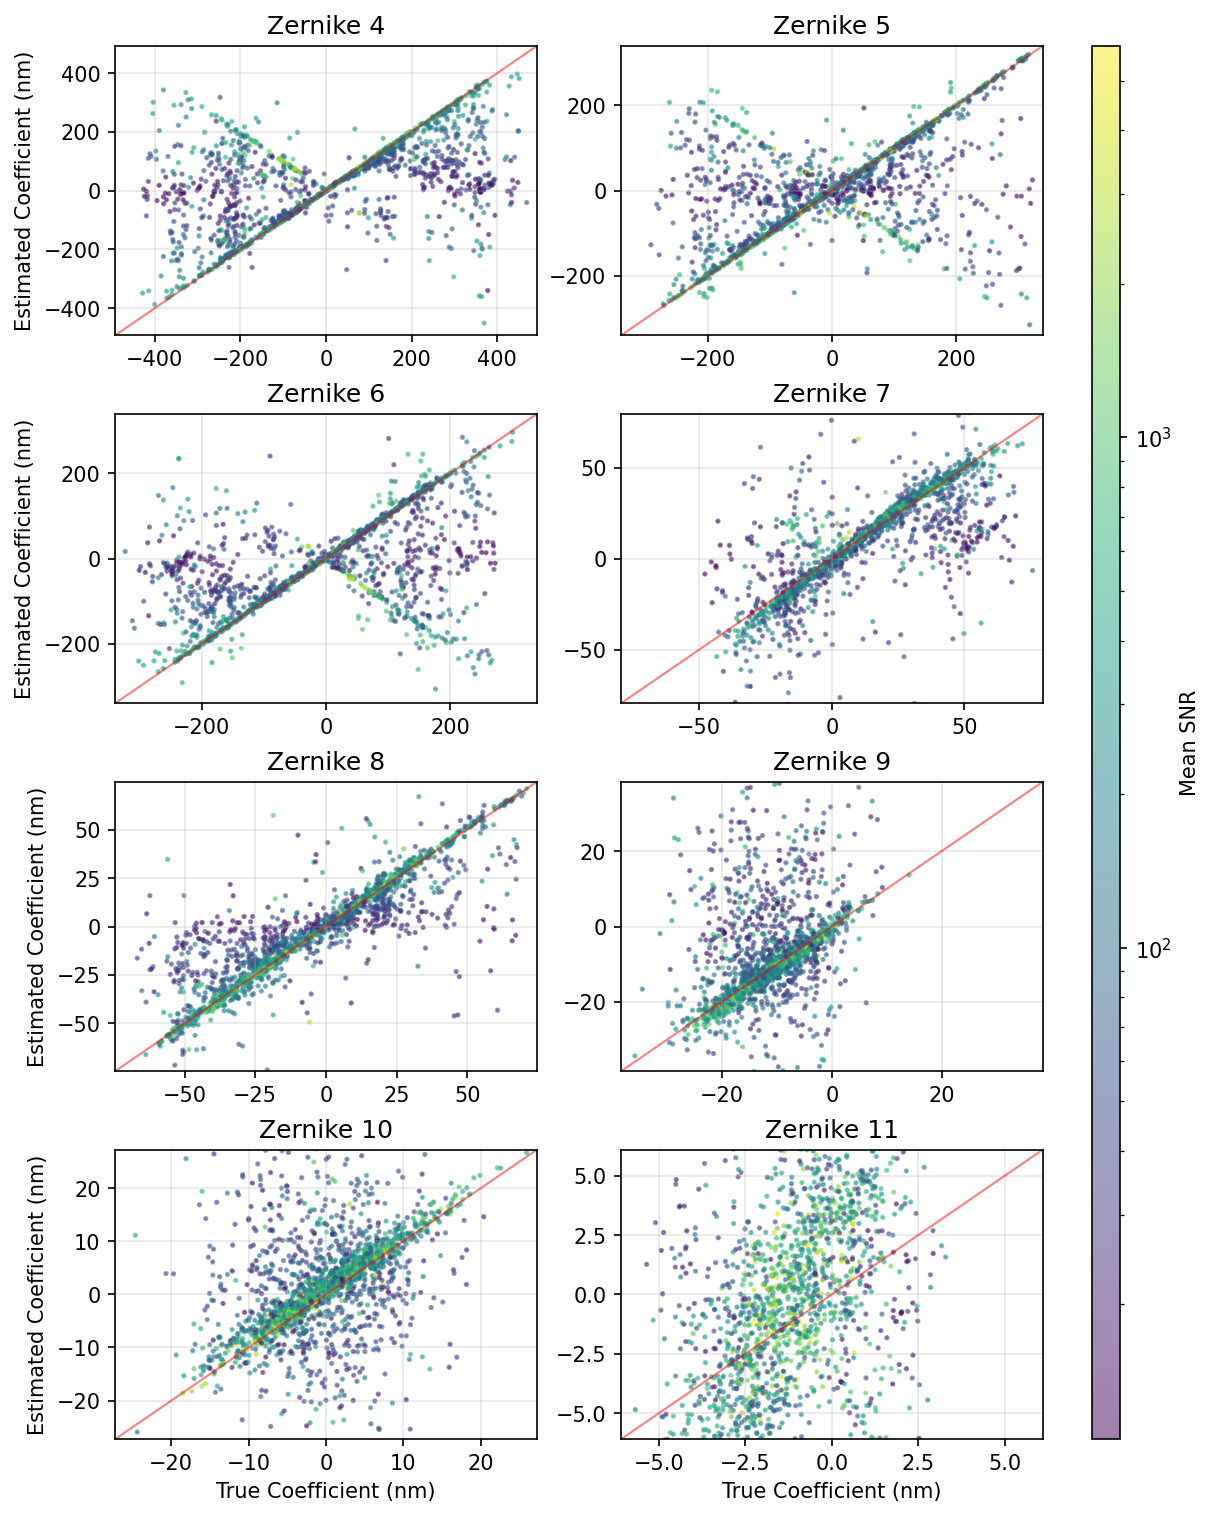

In [60]:
from matplotlib.colors import LogNorm

fig, axs = plt.subplots(figsize=(8, 10), nrows=4, ncols=2, dpi=150, layout='constrained')

clim = [snr.min(), snr.max() * 1.05]

for i, ax in enumerate(axs.flat):

    m = np.max(np.abs(np.array([tru[:, i].min(), tru[:, i].max()])))

    xlim = ylim = [-m * 1.05, m * 1.05]

    ax.plot(np.array(xlim).get(), np.array(xlim).get(), color='r', linewidth=1, label='Ideal Estimator', alpha=0.5)
    s = ax.scatter(x=tru[:, i], y=est[:, i], c=snr, alpha=0.5, marker='.', s=10, norm=LogNorm())
    s.set_clim(clim)
    ax.grid(which='both', alpha=0.3)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if i in [6, 7]:
        ax.set_xlabel('True Coefficient (nm)')
    if i % 2 == 0:
        ax.set_ylabel('Estimated Coefficient (nm)')
    ax.set_title(f'Zernike {i + 4:.0f}')

plt.colorbar(s, ax=axs, label='Mean SNR', aspect=50)

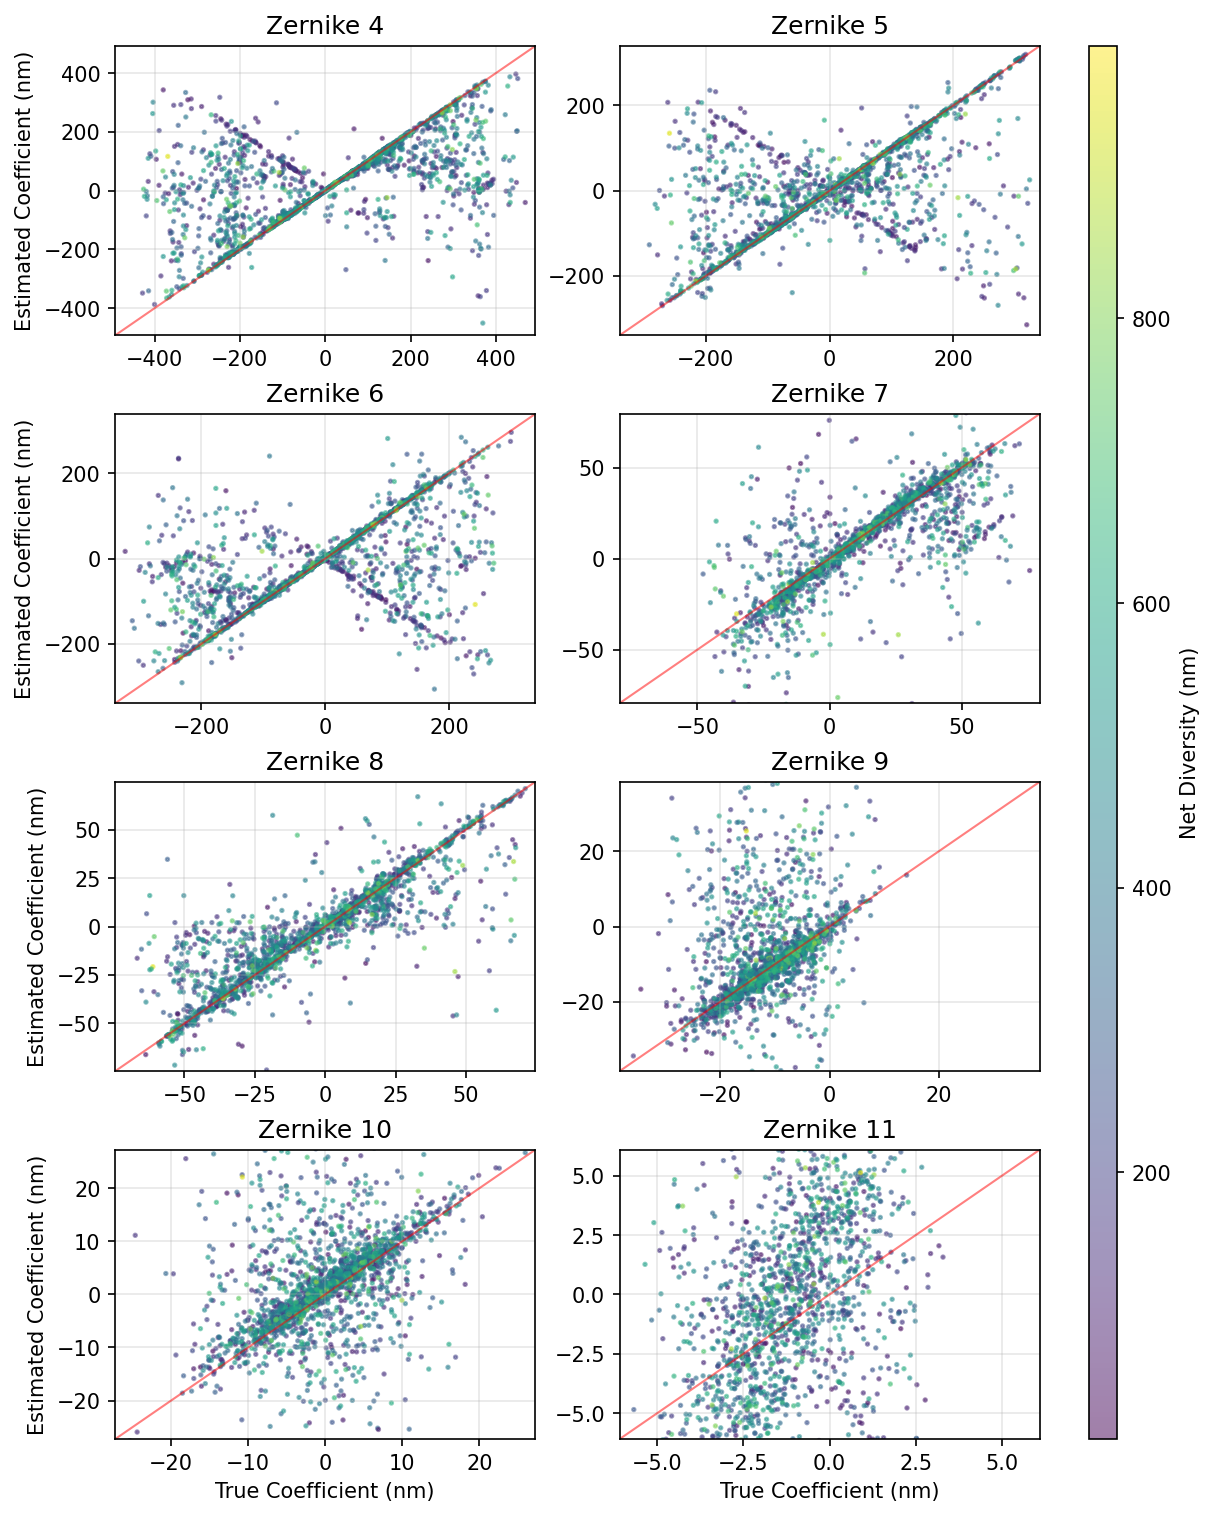

In [59]:
fig, axs = plt.subplots(figsize=(8, 10), nrows=4, ncols=2, dpi=150, layout='constrained')

clim = [div.min() * 0.5, div.max() * 1.05]

for i, ax in enumerate(axs.flat):

    m = np.max(np.abs(np.array([tru[:, i].min(), tru[:, i].max()])))

    xlim = ylim = [-m * 1.05, m * 1.05]

    ax.plot(np.array(xlim).get(), np.array(xlim).get(), color='r', linewidth=1, label='Ideal Estimator', alpha=0.5)
    s = ax.scatter(x=tru[:, i], y=est[:, i], c=div, alpha=0.5, marker='.', s=10)
    s.set_clim(clim)
    ax.grid(which='both', alpha=0.3)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if i in [6, 7]:
        ax.set_xlabel('True Coefficient (nm)')
    if i % 2 == 0:
        ax.set_ylabel('Estimated Coefficient (nm)')
    ax.set_title(f'Zernike {i + 4:.0f}')

plt.colorbar(s, ax=axs, label='Net Diversity (nm)', aspect=50)

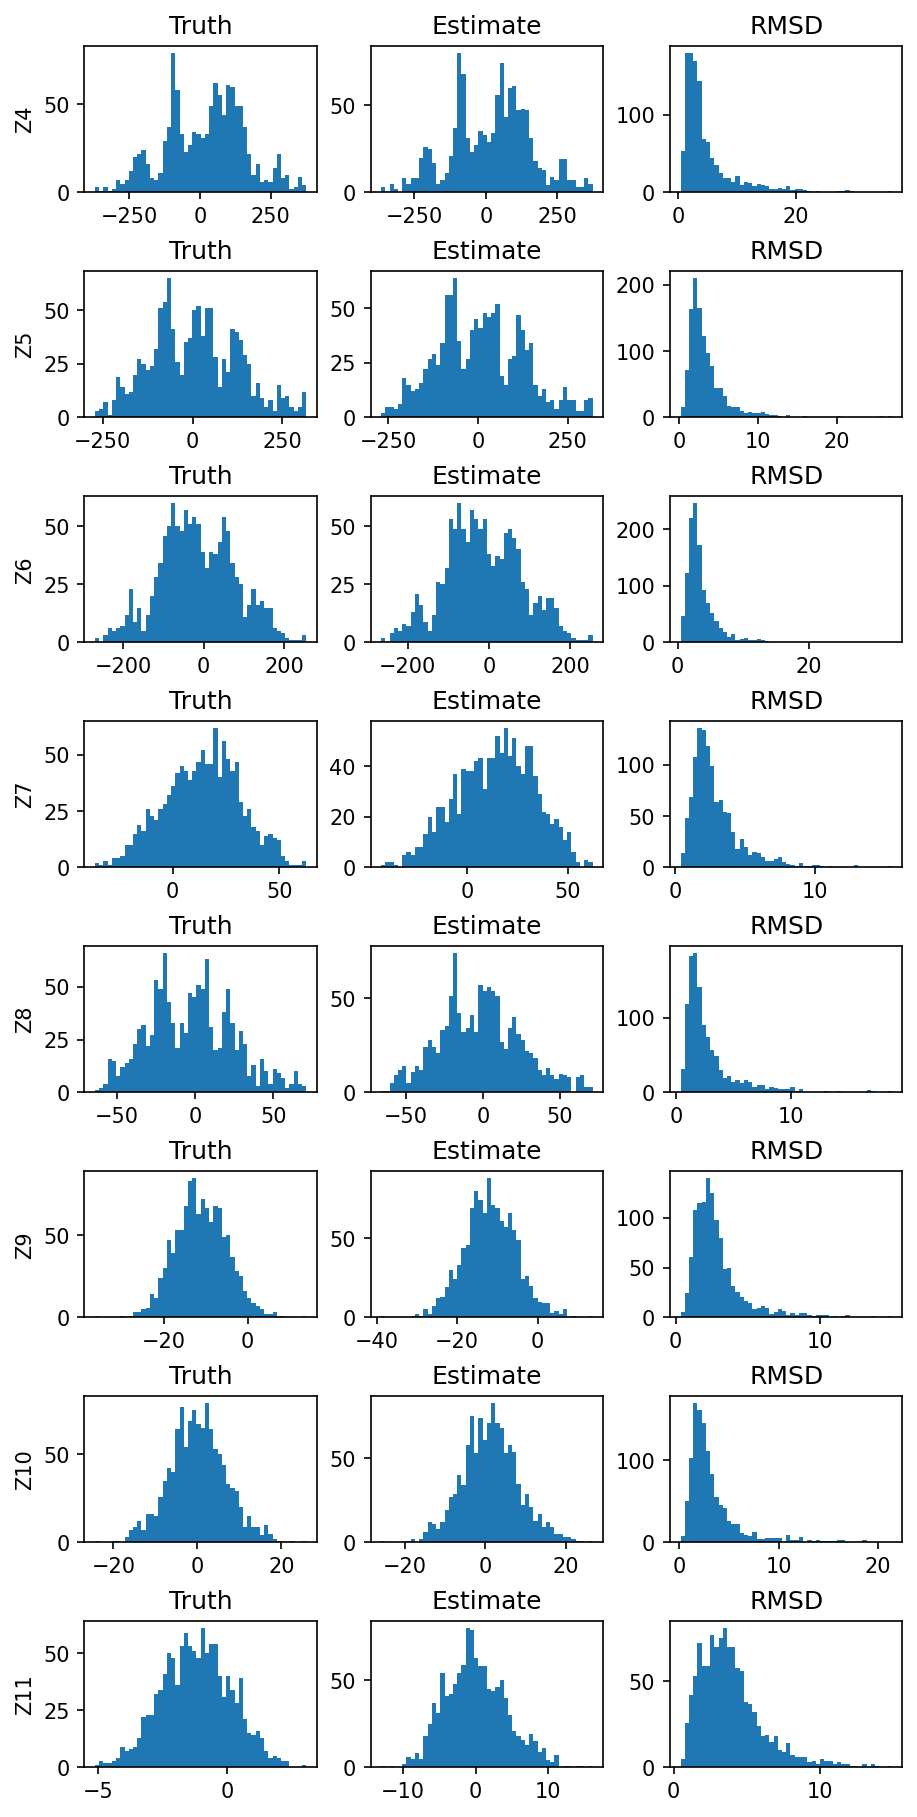

In [41]:
fig, axs = plt.subplots(figsize=(6, 12), nrows=8, ncols=3, dpi=150, layout='constrained')

z = 0
inds = cond < 62.5

for i, ax in enumerate(axs.flat):
    if i % 3 == 0:
        ax.hist(tru[inds, z], bins=50)
        ax.set_title('Truth')
        ax.set_ylabel(f'Z{z + 4:.0f}')
    if i % 3 == 1:
        ax.hist(est[inds, z], bins=50)
        ax.set_title('Estimate')
    if i % 3 == 2:
        ax.hist(diff[inds, z], bins=50)
        ax.set_title('RMSD')
        z += 1

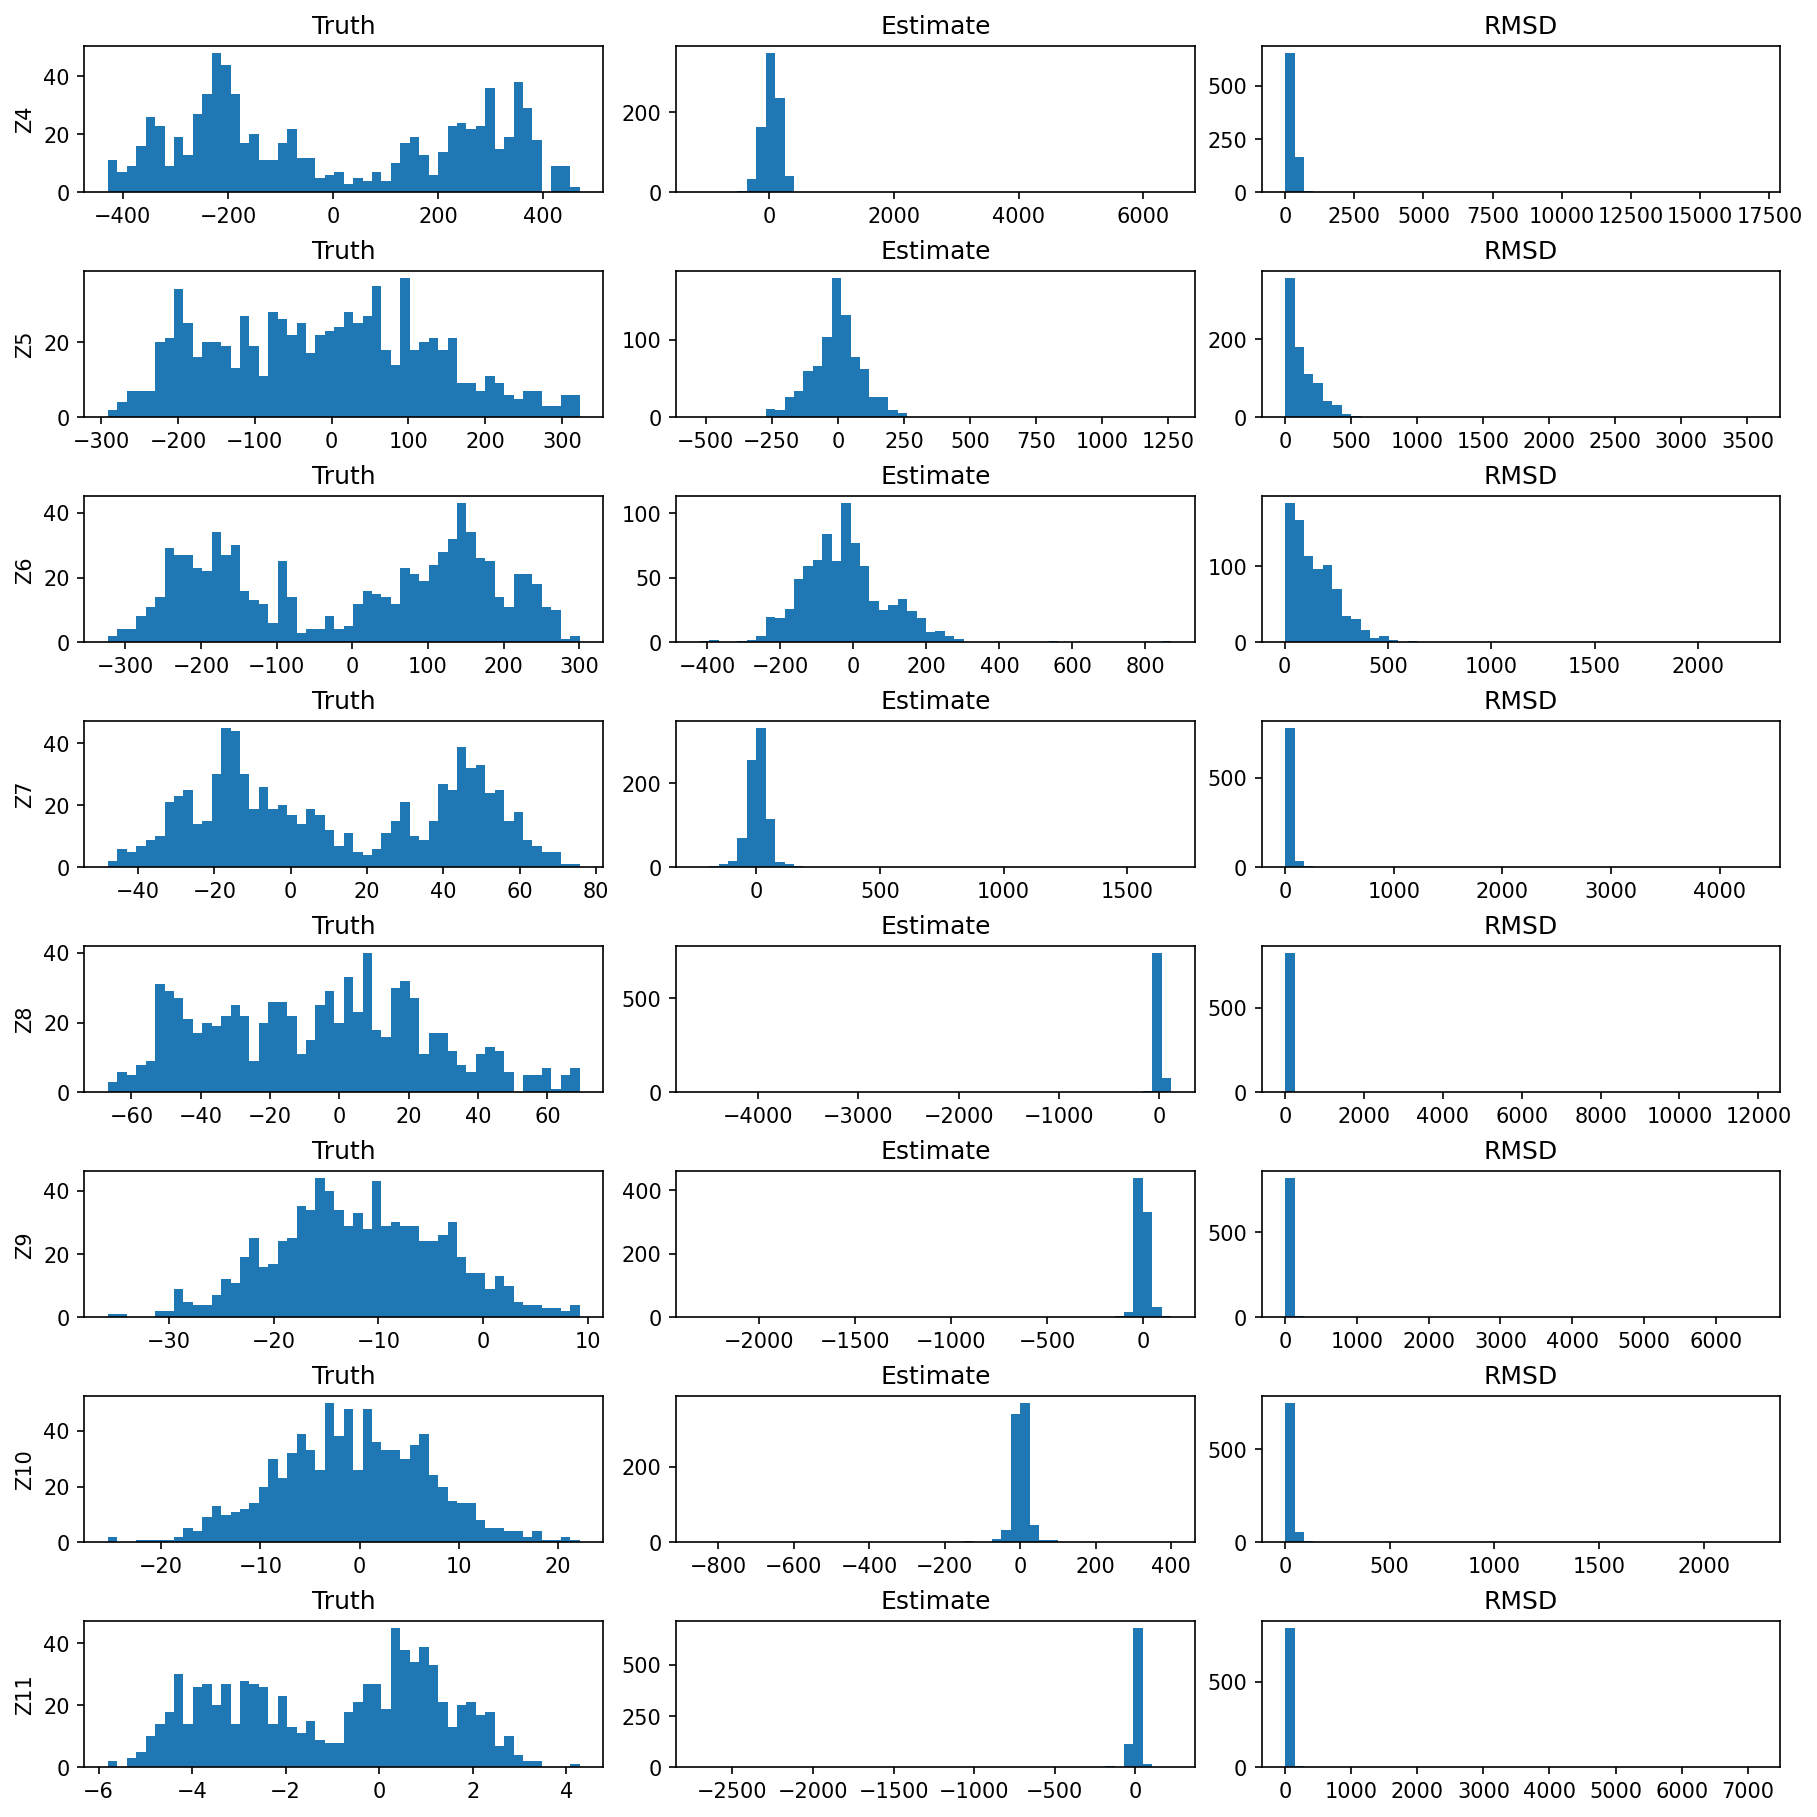

In [43]:
fig, axs = plt.subplots(figsize=(12, 12), nrows=8, ncols=3, dpi=150, layout='constrained')

z = 0
inds = cond > 62.5

for i, ax in enumerate(axs.flat):
    if i % 3 == 0:
        ax.hist(tru[inds, z], bins=50)
        ax.set_title('Truth')
        ax.set_ylabel(f'Z{z + 4:.0f}')
    if i % 3 == 1:
        ax.hist(est[inds, z], bins=50)
        ax.set_title('Estimate')
    if i % 3 == 2:
        ax.hist(diff[inds, z], bins=50)
        ax.set_title('RMSD')
        z += 1

### residual vs snr + rms wfe

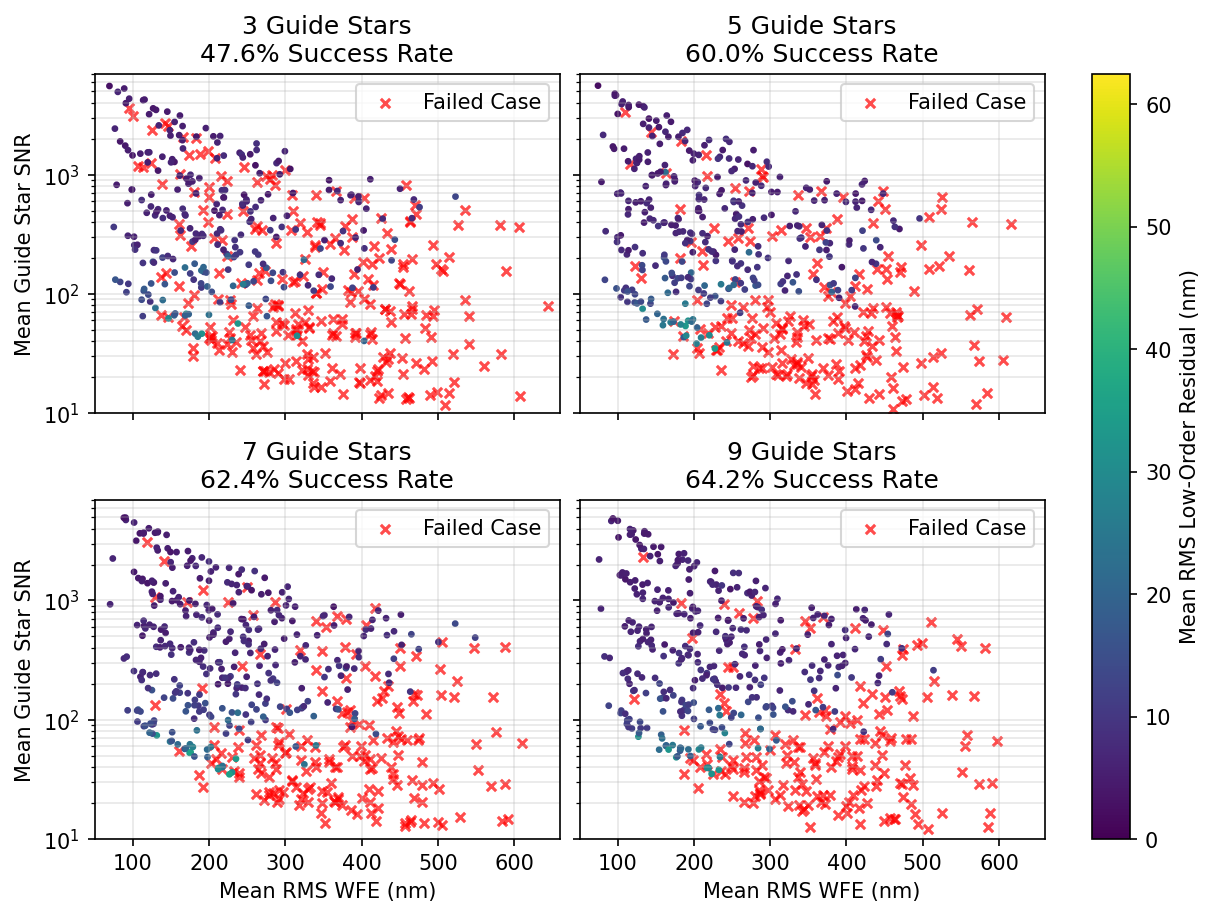

In [5]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

xlim = [50, 660]
ylim = [10, 7000]
titles = [f'{n:.0f} Guide Stars' for n in [3, 5, 7, 9]]

fig, axs = plt.subplots(figsize=(8, 6), nrows=2, ncols=2, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'mean_wfe.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_low.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=1, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 500 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    if i in [2, 3]:
        ax.set_xlabel('Mean RMS WFE (nm)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_ylim(ylim)
    if i in [0, 2]:
        ax.set_ylabel('Mean Guide Star SNR')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

plt.colorbar(s, ax=axs, label='Mean RMS Low-Order Residual (nm)')


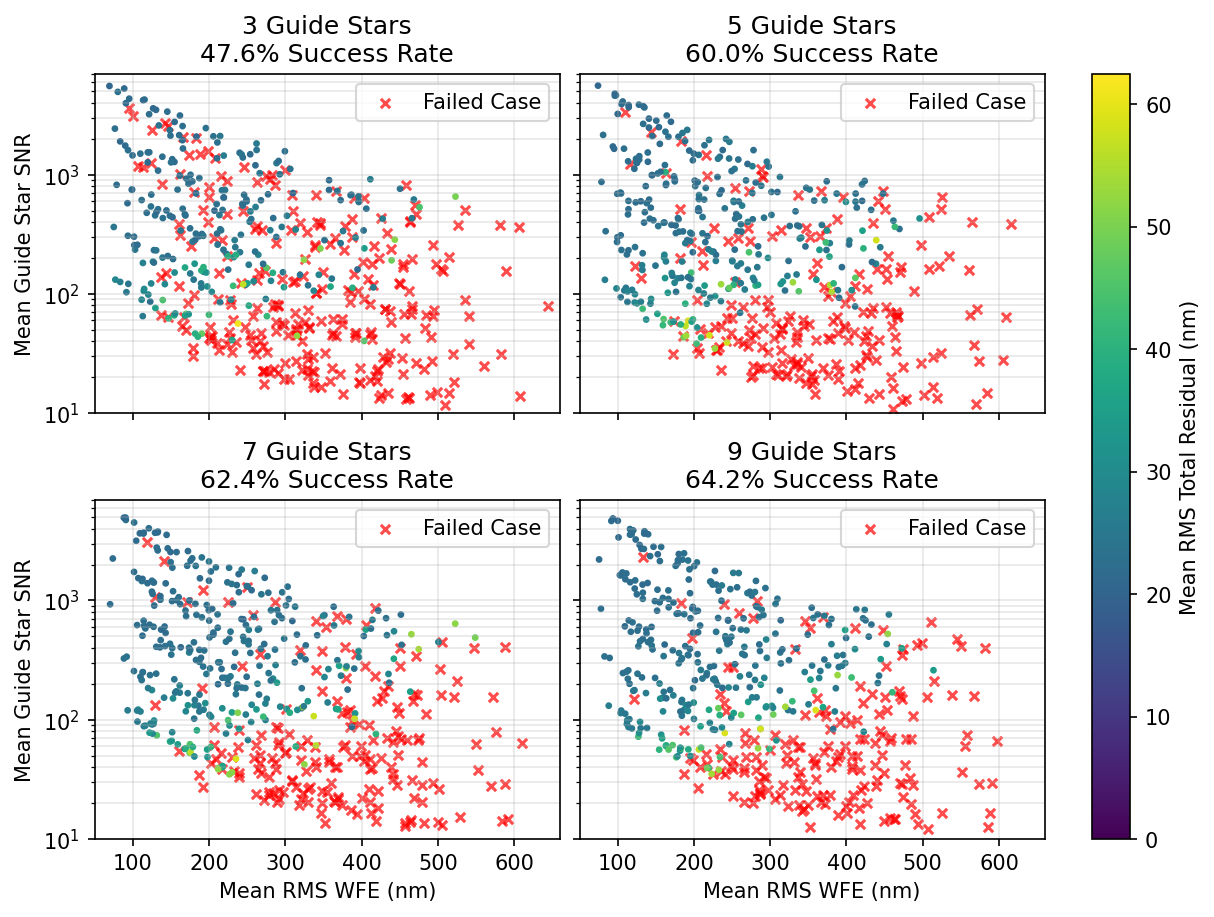

In [6]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

xlim = [50, 660]
ylim = [10, 7000]
titles = [f'{n:.0f} Guide Stars' for n in [3, 5, 7, 9]]

fig, axs = plt.subplots(figsize=(8, 6), nrows=2, ncols=2, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'mean_wfe.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=1, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 500 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    if i in [2, 3]:
        ax.set_xlabel('Mean RMS WFE (nm)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_ylim(ylim)
    if i in [0, 2]:
        ax.set_ylabel('Mean Guide Star SNR')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

plt.colorbar(s, ax=axs, label='Mean RMS Total Residual (nm)')


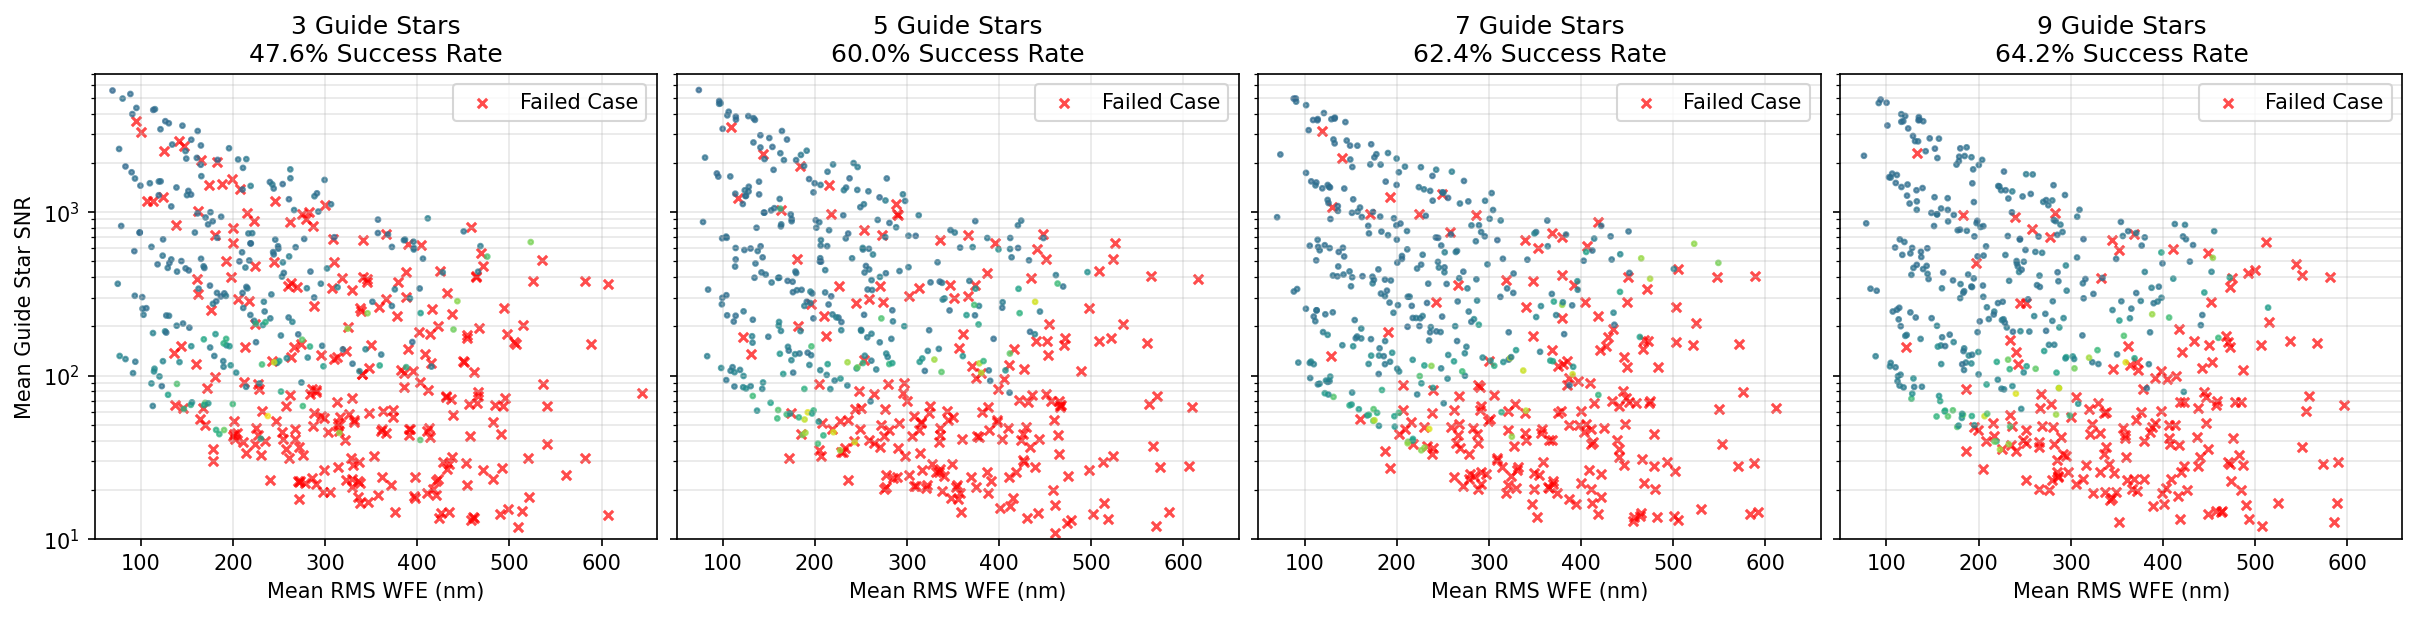

In [7]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

xlim = [50, 660]
ylim = [10, 7000]
titles = [f'{n:.0f} Guide Stars' for n in [3, 5, 7, 9]]

fig, axs = plt.subplots(figsize=(16, 4), nrows=1, ncols=4, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'mean_wfe.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=0.7, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 500 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    ax.set_xlabel('Mean RMS WFE (nm)')


    ax.set_ylim(ylim)
    if i == 0:
        ax.set_ylabel('Mean Guide Star SNR')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

# plt.colorbar(s, ax=axs, label='Mean RMS Total Residual (nm)')


### residual vs snr + net diversity

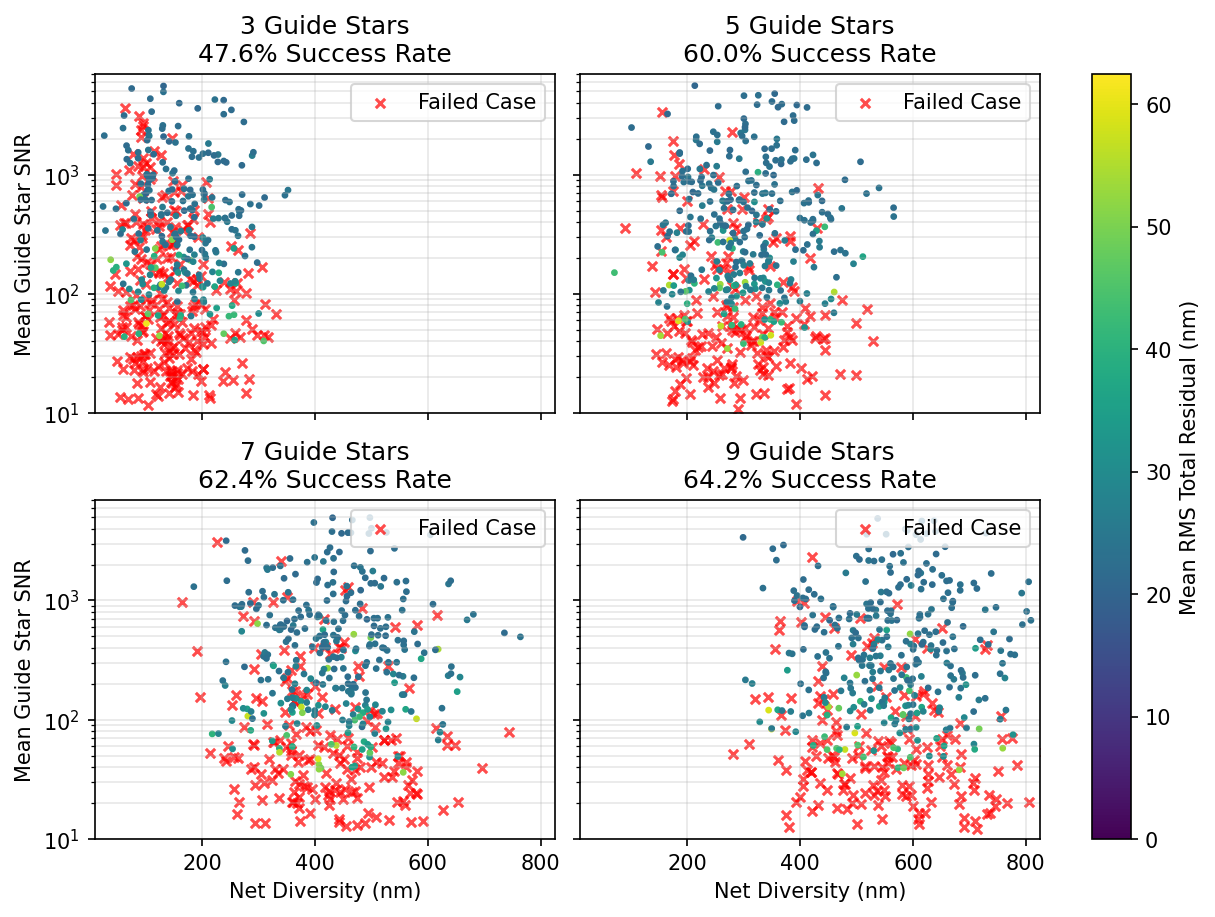

In [7]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

xlim = [10, 825]
ylim = [10, 7000]
titles = [f'{n:.0f} Guide Stars' for n in [3, 5, 7, 9]]

fig, axs = plt.subplots(figsize=(8, 6), nrows=2, ncols=2, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'net_divs.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=1, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 500 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    if i in [2, 3]:
        ax.set_xlabel('Net Diversity (nm)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_ylim(ylim)
    if i in [0, 2]:
        ax.set_ylabel('Mean Guide Star SNR')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

plt.colorbar(s, ax=axs, label='Mean RMS Total Residual (nm)')


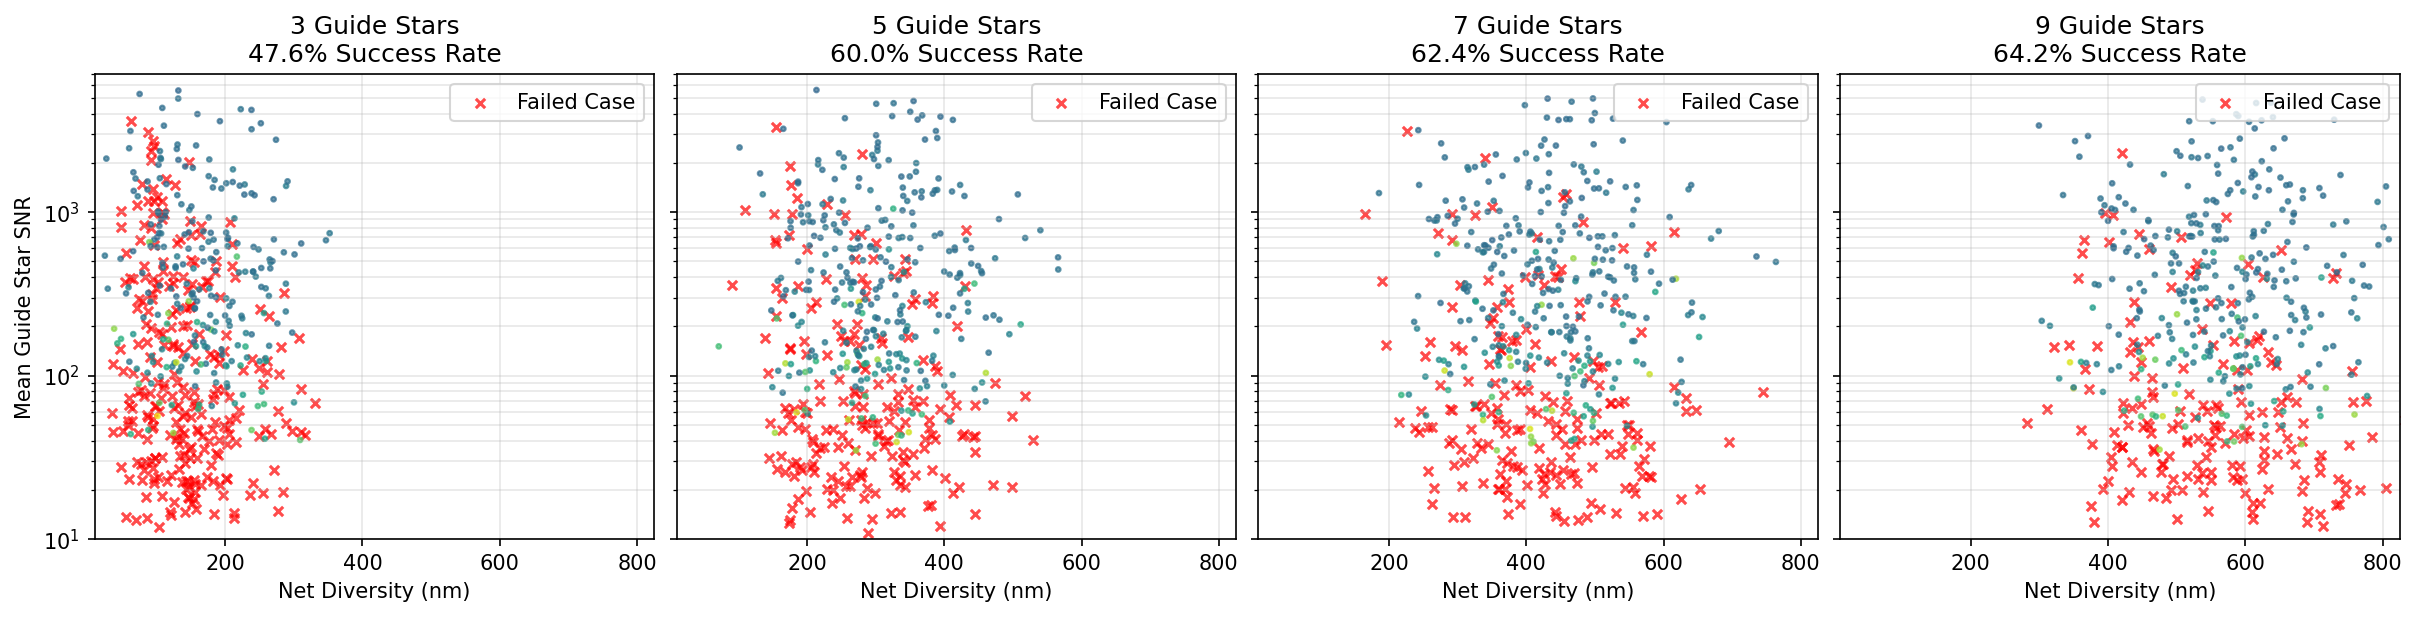

In [8]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

xlim = [10, 825]
ylim = [10, 7000]
titles = [f'{n:.0f} Guide Stars' for n in [3, 5, 7, 9]]

fig, axs = plt.subplots(figsize=(16, 4), nrows=1, ncols=4, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'net_divs.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=0.7, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 500 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    ax.set_xlabel('Net Diversity (nm)')

    ax.set_ylim(ylim)
    if i == 0:
        ax.set_ylabel('Mean Guide Star SNR')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

# plt.colorbar(s, ax=axs, label='Mean RMS Total Residual (nm)')


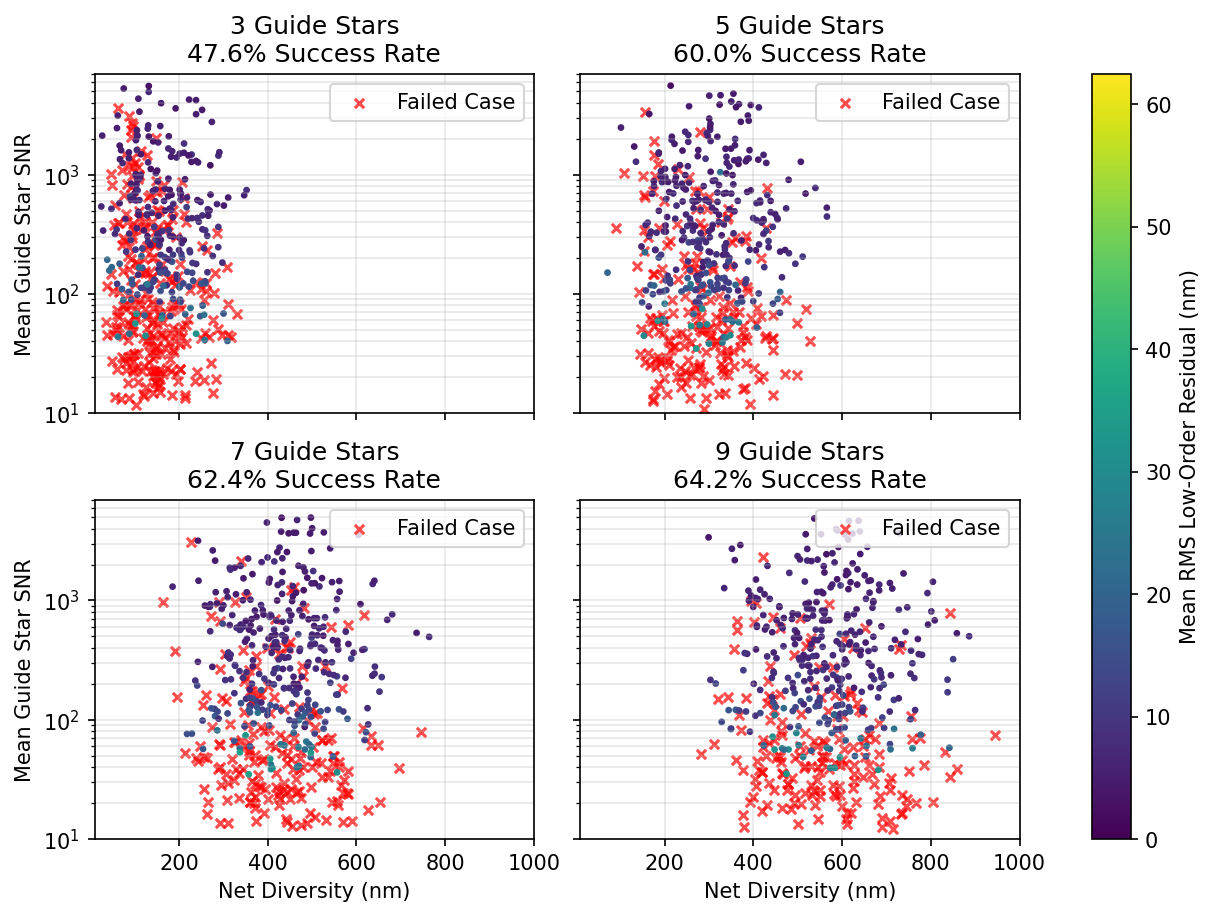

In [8]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{n:.0f}_nsrc_{m:.0f}_randf_true/' for n in [15, 16, 17, 18, 19]] for m in [3, 5, 7, 9]]

xlim = [10, 1000]
ylim = [10, 7000]
titles = [f'{n:.0f} Guide Stars' for n in [3, 5, 7, 9]]

fig, axs = plt.subplots(figsize=(8, 6), nrows=2, ncols=2, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'net_divs.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'mean_snr.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_low.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=1, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 500 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    if i in [2, 3]:
        ax.set_xlabel('Net Diversity (nm)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_ylim(ylim)
    if i in [0, 2]:
        ax.set_ylabel('Mean Guide Star SNR')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

plt.colorbar(s, ax=axs, label='Mean RMS Low-Order Residual (nm)')


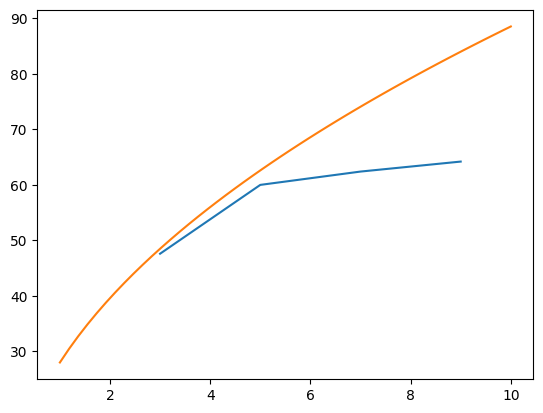

In [15]:
y = np.array([47.6, 60., 62.4, 64.2])
x = np.array([3, 5, 7, 9])

plt.plot(x.get(), y.get())

x = np.linspace(1, 10)
y = np.sqrt(x) * 28

plt.plot(x.get(), y.get())

### residual vs net diversity + rms wfe

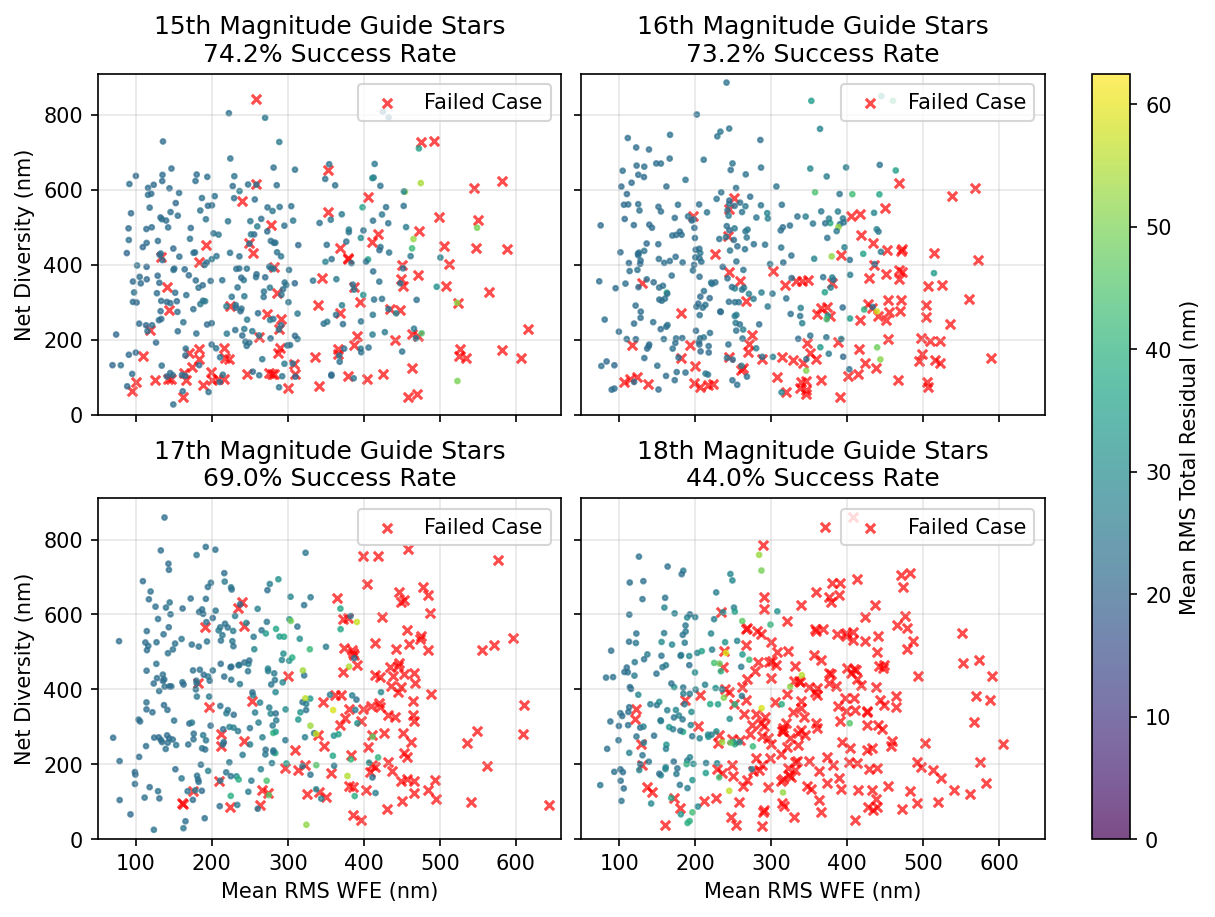

In [41]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{m:.0f}_nsrc_{n:.0f}_randf_true/' for n in [3, 5, 7, 9]] for m in [15, 16, 17, 18]]

xlim = [50, 660]
ylim = [0, 910]
titles = [f'{n:.0f}th Magnitude Guide Stars' for n in [15, 16, 17, 18]]

fig, axs = plt.subplots(figsize=(8, 6), nrows=2, ncols=2, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'mean_wfe.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'net_divs.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    # ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=0.7, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 400 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    if i in [2, 3]:
        ax.set_xlabel('Mean RMS WFE (nm)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_ylim(ylim)
    if i in [0, 2]:
        ax.set_ylabel('Net Diversity (nm)')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

plt.colorbar(s, ax=axs, label='Mean RMS Total Residual (nm)')


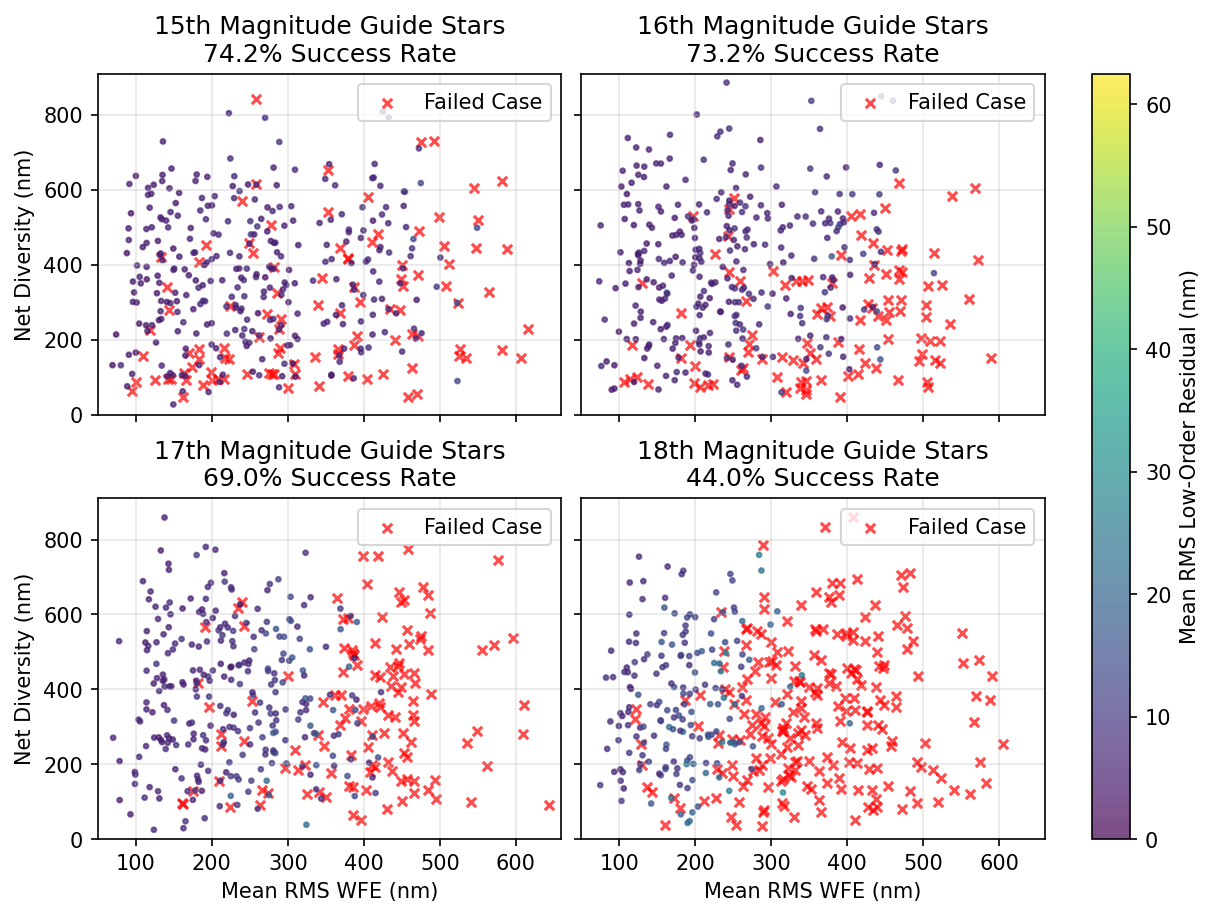

In [42]:
fpathss = [[f'/npool/nvme/derbyk/20260616_mfpr_mc/mis_med_srcmag_{m:.0f}_nsrc_{n:.0f}_randf_true/' for n in [3, 5, 7, 9]] for m in [15, 16, 17, 18]]

xlim = [50, 660]
ylim = [0, 910]
titles = [f'{n:.0f}th Magnitude Guide Stars' for n in [15, 16, 17, 18]]

fig, axs = plt.subplots(figsize=(8, 6), nrows=2, ncols=2, dpi=150, layout='constrained')

for i, (ax, fpaths) in enumerate(zip(axs.flat, fpathss)):

    x = _np.empty(0)
    y = _np.empty(0)
    c = _np.empty(0)
    cond = _np.empty(0)

    for fpath in fpaths:
        x = _np.concatenate((x, fits.getdata(fpath + 'mean_wfe.fits')), axis=0)
        y = _np.concatenate((y, fits.getdata(fpath + 'net_divs.fits')), axis=0)
        c = _np.concatenate((c, fits.getdata(fpath + 'mean_residual_low.fits')), axis=0)
        cond = _np.concatenate((cond, fits.getdata(fpath + 'mean_residual_all.fits')), axis=0)

    inds = cond < 62.5

    cmin = 0
    cmax = 62.5

    ax.scatter(x[~inds], y[~inds], c='r', alpha=0.7, marker='x', label='Failed Case', s=20)
    # ax.set_yscale('log')
    s = ax.scatter(x[inds], y[inds], c=c[inds], alpha=0.7, marker='.', s=20)
    s.set_clim([cmin, cmax])
    ax.grid(which='both', alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_title(titles[i] + f'\n{_np.sum(inds) / 400 * 100:.1f}% Success Rate')

    ax.set_xlim(xlim)
    if i in [2, 3]:
        ax.set_xlabel('Mean RMS WFE (nm)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_ylim(ylim)
    if i in [0, 2]:
        ax.set_ylabel('Net Diversity (nm)')
    else:
        ax.tick_params(axis='y', labelleft=False)
    

plt.colorbar(s, ax=axs, label='Mean RMS Low-Order Residual (nm)')


### sci ops

In [5]:
from prysm.psf import fwhm
from astropy.modeling import models, fitting

In [6]:
fpath = '/npool/nvme/derbyk/20260616_mfpr_mc/'
fname = '/mis_smol_srcmag_19_nsrc_3_randf_true_nframes_1_exp_360_sci'
# fname = '/mis_smol_srcmag_19_nsrc_3_randf_true_nframes_1_exp_360_sci_calib_perf'

data = utils.load_pickle(fpath + fname + '.pkl')

In [7]:
avg_dists = _np.zeros(len(data))
areas = _np.zeros(len(data))

for i, case in enumerate(data):

    sci_field = data[case]['SCI_FIELD']
    guide_fields = data[case]['FIELDS']

    dists = _np.zeros(3)

    for j, guide_field in enumerate(guide_fields[:-1]):
        dists[j] = _np.sqrt((sci_field[0] - guide_field[0]) ** 2 + (sci_field[1] - guide_field[1]) ** 2)

    avg_dists[i] = _np.mean(dists)

    hull = ConvexHull(guide_fields[:-1])
    areas[i] = hull.area

In [8]:
mean_snr = np.zeros(len(data))
mean_res_all = np.zeros(len(data))
mean_res_low = np.zeros(len(data))
mean_err = np.zeros(len(data))

for i, case in enumerate(data):
    print('ANALYZING CASE ' + str(i + 1), end='\r')

    # mean snr per case
    snrs = data[case]['SNR_PER_FIELD']
    mean_snr[i] = np.mean(np.array(snrs))

    # mean rms residuals per case
    opds_est = data[case]['WFE_ESTIMATE']
    opds_tru = data[case]['WFE_TRUTH']

    res_all = []
    res_low = []
    err = []
    ct = np.zeros((len(opds_est), 8))
    ce = np.zeros((len(opds_est), 8))
    cd = np.zeros((len(opds_est), 8))

    for j, (opd_est, opd_tru) in enumerate(zip(copy.deepcopy(opds_est), copy.deepcopy(opds_tru))):

        # total residual
        opd_diff = opd_est - opd_tru
        opd_diff[~amp] = np.nan
        opd_diff -= np.nanmean(opd_diff)
        res_all.append(np.sqrt(np.nanmean(opd_diff ** 2)))

        # low order residual
        opd_est[~amp] = np.nan
        opd_tru[~amp] = np.nan
        opd_est -= np.nanmean(opd_est)
        opd_tru -= np.nanmean(opd_tru)
        c_est = lstsq(zernikes, opd_est)[3:11]
        c_tru = lstsq(zernikes, opd_tru)[3:11]

        oe = sum_of_2d_modes(np.array(zernikes[3:11]), c_est) * amp
        ot = sum_of_2d_modes(np.array(zernikes[3:11]), c_tru) * amp
        res_low.append(np.sqrt(np.mean((oe - ot) ** 2)))

        # ground truth error
        err.append(np.sqrt(np.nanmean(opd_tru ** 2)))

    mean_res_all[i] = np.mean(np.array(res_all))
    mean_res_low[i] = np.mean(np.array(res_low))
    mean_err[i] = np.mean(np.array(err))

In [9]:
fwhm_x_tru = _np.zeros(len(data))
fwhm_x_est = _np.zeros(len(data))
fwhm_y_tru = _np.zeros(len(data))
fwhm_y_est = _np.zeros(len(data))

for i, case in enumerate(data):
    print('ANALYZING CASE ' + str(i + 1), end='\r')

    wfe_sci_est = data[case]['SCI_ESTIMATE']
    wfe_sci_tru = data[case]['SCI_TRUTH']

    im = data[case]['SCI_IMAGE'].get()
    im /= im.max()

    dx = sys.cfg['optics']['m1']['diam'] / sys.cfg['general']['npix_pupil']
    wvls = sys.wvls

    psf_sci_est = 0
    psf_sci_tru = 0
    for wvl in wvls.tolist():
        wf = WF.from_amp_and_phase(amplitude=amp, phase=wfe_sci_est, wavelength=wvl, dx=dx)
        psf_sci_est += np.abs(wf.focus_fixed_sampling(efl=sys.cfg['general']['f_eff'], dx=sys.cfg['detector']['dx_focal'], 
                                                    samples=sys.cfg['general']['npix_focal'], shift=(0, 0), method='mdft').data) ** 2
        wf = WF.from_amp_and_phase(amplitude=amp, phase=wfe_sci_tru, wavelength=wvl, dx=dx)
        psf_sci_tru += np.abs(wf.focus_fixed_sampling(efl=sys.cfg['general']['f_eff'], dx=sys.cfg['detector']['dx_focal'], 
                                                    samples=sys.cfg['general']['npix_focal'], shift=(0, 0), method='mdft').data) ** 2
    psf_sci_est /= psf_sci_est.max()
    psf_sci_tru /= psf_sci_tru.max()

    dim = psf_sci_tru.shape[0]
    x = y = _np.linspace(-dim / 2 + 0.5, dim / 2 - 0.5, dim)
    x, y = _np.meshgrid(x, y)

    # gaussian model
    m = models.Gaussian2D(amplitude=1, x_mean=0, y_mean=0, x_stddev=2, y_stddev=2)

    # fit
    fitter = fitting.LevMarLSQFitter()
    fit_tru = fitter(m, x, y, im)
    # fit_tru = fitter(m, x, y, psf_sci_tru.get())
    fit_est = fitter(m, x, y, psf_sci_est.get())

    fwhm_x_tru[i] = fit_tru.x_stddev.value * 2.35482
    fwhm_y_tru[i] = fit_tru.y_stddev.value * 2.35482

    fwhm_x_est[i] = fit_est.x_stddev.value * 2.35482
    fwhm_y_est[i] = fit_est.y_stddev.value * 2.35482


Text(0.5, 1.0, 'Mean: -0.10%\n Standard Deviation: 4.21%')

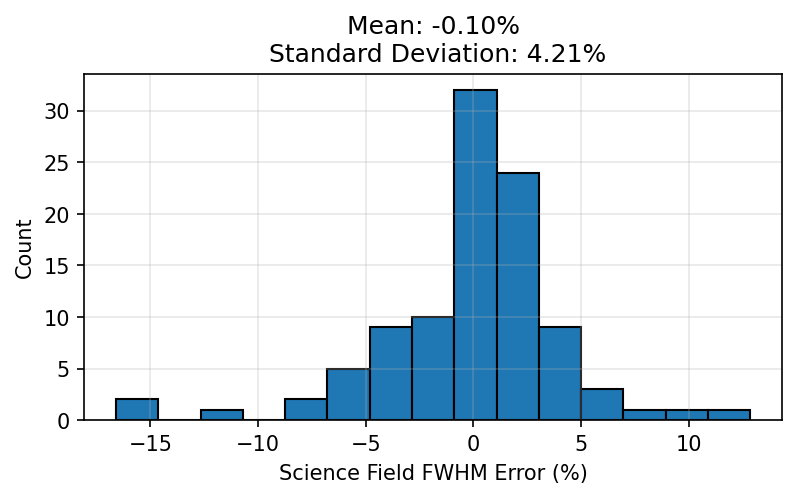

In [10]:
err_x = (fwhm_x_est - fwhm_x_tru) / fwhm_x_tru * 100
err_y = (fwhm_y_est - fwhm_y_tru) / fwhm_y_tru * 100
err_avg = _np.mean([err_x, err_y], axis=0)

plt.figure(figsize=(6, 3), dpi=150)
plt.hist(err_avg, bins=15, edgecolor='k')
plt.xlabel('Science Field FWHM Error (%)')
plt.ylabel('Count')
plt.grid(which='both', alpha=0.3)
plt.title(f'Mean: {_np.mean(err_avg):.2f}%\n Standard Deviation: {_np.std(err_avg):.2f}%')

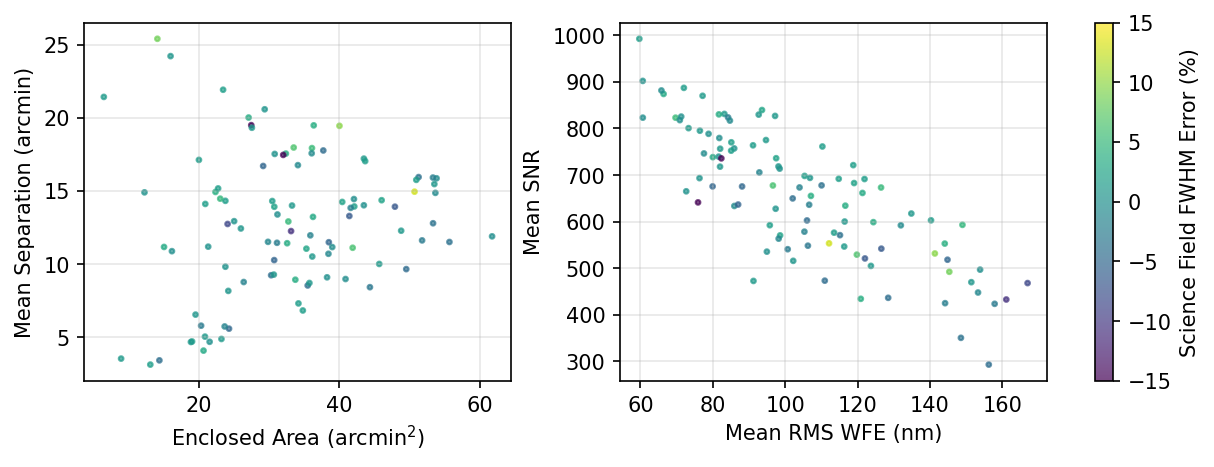

In [45]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3), dpi=150, layout='constrained')

ax = axs[0]
s = ax.scatter(x=areas, y=avg_dists, c=err_avg, marker='.', alpha=0.7, s=20)
ax.grid(which='both', alpha=0.3)
s.set_clim([-15, 15])
ax.set_xlabel('Enclosed Area (arcmin$^2$)')
ax.set_ylabel('Mean Separation (arcmin)')

ax = axs[1]
s = ax.scatter(x=mean_err.get(), y=mean_snr.get(), c=err_avg, marker='.', alpha=0.7, s=20)
ax.grid(which='both', alpha=0.3)
s.set_clim([-15, 15])
ax.set_xlabel('Mean RMS WFE (nm)')
ax.set_ylabel('Mean SNR')

plt.colorbar(s, ax=axs, label='Science Field FWHM Error (%)')

## snr + opd

In [2]:
data1 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_15mag_dec_50um_tilt_5as.pkl')
data2 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_16mag_dec_50um_tilt_5as.pkl')
data3 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_17mag_dec_50um_tilt_5as.pkl')
data4 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_18mag_dec_50um_tilt_5as.pkl')
data5 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_19mag_dec_50um_tilt_5as.pkl')

median_rms_truth = np.zeros(len(data1) * 5)
median_rms_residual = np.zeros(len(data1) * 5)
max_rms_residual = np.zeros(len(data1) * 5)
min_rms_residual = np.zeros(len(data1) * 5)
std_rms_residual = np.zeros(len(data1) * 5)
median_snr = np.zeros(len(data1) * 5)

data = data1
for i, case in enumerate(data):
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

data = data2
for i, case in enumerate(data):
    i += 100
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

data = data3
for i, case in enumerate(data):
    i += 200
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

data = data4
for i, case in enumerate(data):
    i += 300
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

data = data5
for i, case in enumerate(data):
    i += 400
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

In [22]:
count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min() * 0.9
xmax = _np.array([xs.max(), fails_x.max()]).max() * 1.02

ymin = _np.array([ys.min(), fails_y.min()]).min() * 0.
ymax = _np.array([ys.max(), fails_y.max()]).max() * 1.1

cmin = 20
cmax = 62.5

sorted_fails_x = sorted(fails_x)
cdf_opd = [0]
cdf_x = [xmin ]
x = xmin
count = 0
while x < xmax:
    if count == len(fails_x):
        x += 10
        break
    if x + 10 < sorted_fails_x[count]:
        x += 10
        cdf_x.append(x)
        cdf_opd.append(cdf_opd[-1])
    else:
        x = sorted_fails_x[count]
        cdf_x.append(x)
        cdf_opd.append((((count + 1) / 500)))
        count += 1
cdf_x.append(xmax )
cdf_opd.append(cdf_opd[-1])
cdf_opd = _np.array(cdf_opd)
cdf_x = _np.array(cdf_x)

sorted_fails_y = _np.flip(sorted(fails_y))
cdf_snr = [0]
cdf_y = [ymax ]
y = ymax
count = 0
while y > ymin:
    if count == len(fails_y):
        y -= 10
        break
    if y - 10 > sorted_fails_y[count]:
        y -= 10
        cdf_y.append(y)
        cdf_snr.append(cdf_snr[-1])
    else:
        y = sorted_fails_y[count]
        cdf_y.append(y)
        cdf_snr.append((((count + 1) / 500)))
        count += 1
cdf_y.append(ymin )
cdf_snr.append(cdf_snr[-1])
cdf_snr = _np.array(cdf_snr)
cdf_y = _np.array(cdf_y)

/tmp/ipykernel_1029268/907950454.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([ymin , ymax ])
/tmp/ipykernel_1029268/907950454.py:43: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([ymin , ymax ])


Text(0.5, 0.98, 'RMag 15, 16, 17, 18, 19 Combined\n100 Misalignment Cases per RMag; 71% Overall Success Rate\n$\\pm25\\mu m$ Decenter X, Y and $\\pm2.5$" Tilt X, Y on M1 - M4')

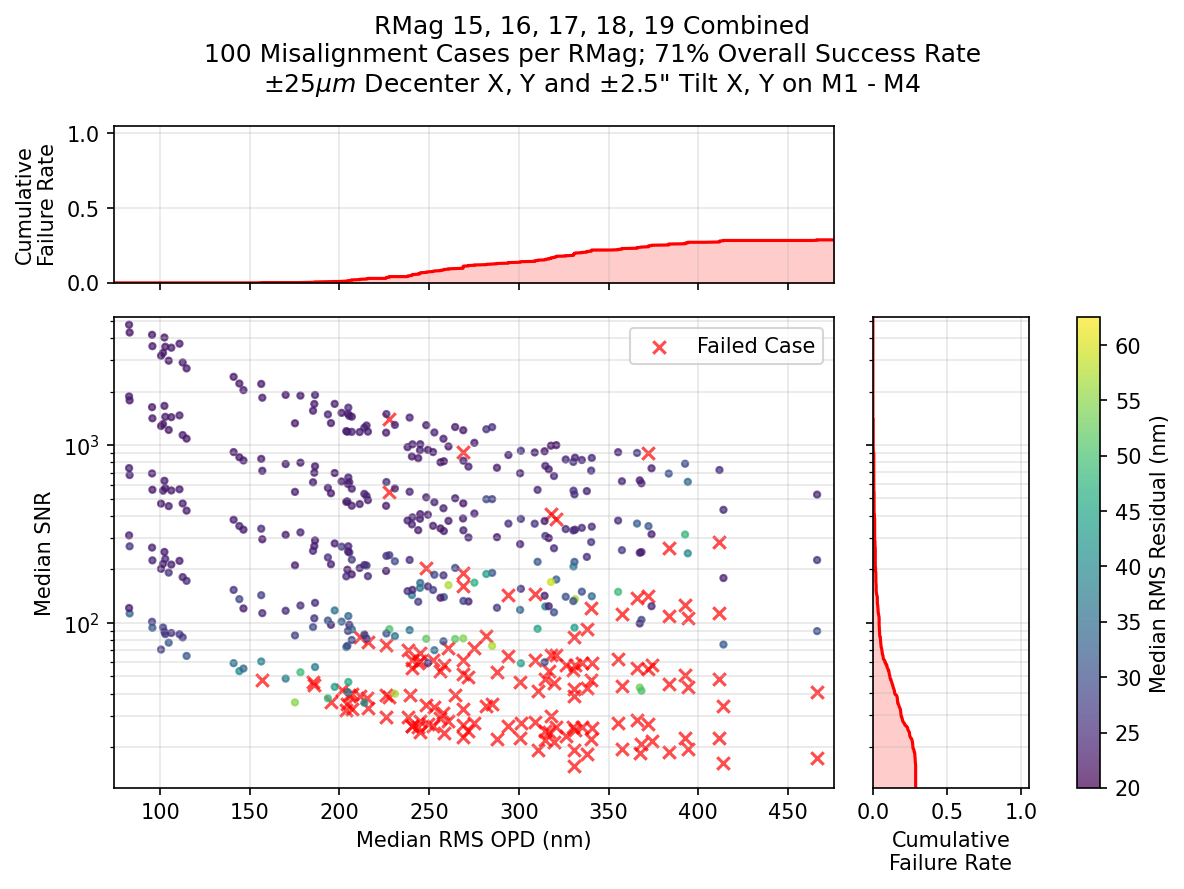

In [31]:

fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(8, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

axs['poop'].set_axis_off()

ax = axs['scatter']
ax.scatter(fails_x, fails_y, c='r', alpha=0.7, marker='x', label='Failed Case')
ax.set_yscale('log')
s = ax.scatter(xs, ys, c=cs, alpha=0.7, marker='.')
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD (nm)')
ax.set_ylabel('Median SNR')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([ymin , ymax ])
ax.grid(which='both', alpha=0.3)
ax.legend(loc='upper right')

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual (nm)')

ax = axs['histx']
ax.plot(cdf_x, cdf_opd, color='r')
ax.fill_between(cdf_x, cdf_opd, alpha=0.2, color='r')
# ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Cumulative\nFailure Rate')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([0, 1.05])
ax.grid(which='both', alpha=0.3)

ax = axs['histy']
ax.plot(cdf_snr, cdf_y, color='r')
ax.fill_betweenx(cdf_y, cdf_snr, alpha=0.2, color='r')
ax.set_yscale('log')
# ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xticks([0, 0.5, 1])
ax.set_xlabel('Cumulative\nFailure Rate')
ax.set_ylim([ymin , ymax ])
ax.set_xlim([0, 1.05])
ax.grid(which='both', alpha=0.3)


fig.suptitle(f'RMag 15, 16, 17, 18, 19 Combined\n{len(data):02.0f} Misalignment Cases per RMag; {len(cs) / 500 * 100:02.0f}% Overall Success Rate\n$\pm25\mu m$ Decenter X, Y and $\pm2.5$" Tilt X, Y on M1 - M4')


## diversity + opd

In [20]:
data1 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260505_mc_misalignments_3stars_dec_50um_tilt_5as.pkl')
data2 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260505_mc_misalignments_7stars_dec_50um_tilt_5as.pkl')
data3 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260505_mc_misalignments_11stars_dec_50um_tilt_5as.pkl')
data4 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260505_mc_misalignments_15stars_dec_50um_tilt_5as.pkl')
data5 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260505_mc_misalignments_19stars_dec_50um_tilt_5as.pkl')

median_rms_truth = np.zeros(len(data1) * 5)
median_rms_residual = np.zeros(len(data1) * 5)
max_rms_residual = np.zeros(len(data1) * 5)
min_rms_residual = np.zeros(len(data1) * 5)
std_rms_residual = np.zeros(len(data1) * 5)
weighted_sum_diversity = np.zeros(len(data1) * 5)
median_snr = np.zeros(len(data1) * 5)

data = data1
for i, case in enumerate(data):
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))
    wsum = 0
    for snr, div in zip(data[case]['SNR_PER_FIELD'], data[case]['RMS_DIVERSITY_PER_FIELD']):
        # wsum += snr / median_snr[i] * div ** 2
        wsum += 200 / 200 * div ** 2
    weighted_sum_diversity[i] = np.sqrt(wsum)

data = data2
for i, case in enumerate(data):
    i += 100
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))
    wsum = 0
    for snr, div in zip(data[case]['SNR_PER_FIELD'], data[case]['RMS_DIVERSITY_PER_FIELD']):
        # wsum += snr / median_snr[i] * div ** 2
        wsum += 200 / 200 * div ** 2
    weighted_sum_diversity[i] = np.sqrt(wsum)

data = data3
for i, case in enumerate(data):
    i += 200
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))
    wsum = 0
    for snr, div in zip(data[case]['SNR_PER_FIELD'], data[case]['RMS_DIVERSITY_PER_FIELD']):
        # wsum += snr / median_snr[i] * div ** 2
        wsum += 200 / 200 * div ** 2
    weighted_sum_diversity[i] = np.sqrt(wsum)

data = data4
for i, case in enumerate(data):
    i += 300
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))
    wsum = 0
    for snr, div in zip(data[case]['SNR_PER_FIELD'], data[case]['RMS_DIVERSITY_PER_FIELD']):
        # wsum += snr / median_snr[i] * div ** 2
        wsum += 200 / 200 * div ** 2
    weighted_sum_diversity[i] = np.sqrt(wsum)

data = data5
for i, case in enumerate(data):
    i += 400
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))
    wsum = 0
    for snr, div in zip(data[case]['SNR_PER_FIELD'], data[case]['RMS_DIVERSITY_PER_FIELD']):
        # wsum += snr / median_snr[i] * div ** 2
        wsum += 200 / 200 * div ** 2
    weighted_sum_diversity[i] = np.sqrt(wsum)

In [21]:
n_stars = np.ones(100) * 3
n_stars = np.concatenate((n_stars, np.ones(100) * 5), axis=0)
n_stars = np.concatenate((n_stars, np.ones(100) * 7), axis=0)
n_stars = np.concatenate((n_stars, np.ones(100) * 9), axis=0)
n_stars = np.concatenate((n_stars, np.ones(100) * 11), axis=0)

In [22]:
count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

# for x, y, c in zip(median_rms_truth, weighted_sum_diversity, median_rms_residual):
#     if c < 62.5:
#         xs.append(float(x))
#         ys.append(float(y))
#         cs.append(float(c))
#     else:
#         fails_x.append(float(x))
#         fails_y.append(float(y))

for x, y, c in zip(weighted_sum_diversity, median_snr, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min() * 0.9
xmax = _np.array([xs.max(), fails_x.max()]).max() * 1.02

ymin = _np.array([ys.min(), fails_y.min()]).min() * 0.9
ymax = _np.array([ys.max(), fails_y.max()]).max() * 1.05

cmin = 20
cmax = 62.5

sorted_fails_x = sorted(fails_x)
cdf_opd = [0]
cdf_x = [xmin ]
x = xmin
count = 0
while x < xmax:
    if count == len(fails_x):
        x += 10
        break
    if x + 10 < sorted_fails_x[count]:
        x += 10
        cdf_x.append(x)
        cdf_opd.append(cdf_opd[-1])
    else:
        x = sorted_fails_x[count]
        cdf_x.append(x)
        cdf_opd.append((((count + 1) / 500)))
        count += 1
cdf_x.append(xmax )
cdf_opd.append(cdf_opd[-1])
cdf_opd = _np.array(cdf_opd)
cdf_x = _np.array(cdf_x)

sorted_fails_y = _np.flip(sorted(fails_y))
cdf_snr = [0]
cdf_y = [ymax ]
y = ymax
count = 0
while y > ymin:
    if count == len(fails_y):
        y -= 10
        break
    if y - 10 > sorted_fails_y[count]:
        y -= 10
        cdf_y.append(y)
        cdf_snr.append(cdf_snr[-1])
    else:
        y = sorted_fails_y[count]
        cdf_y.append(y)
        cdf_snr.append((((count + 1) / 500)))
        count += 1
cdf_y.append(ymin )
cdf_snr.append(cdf_snr[-1])
cdf_snr = _np.array(cdf_snr)
cdf_y = _np.array(cdf_y)

Text(0.5, 0.98, '3, 7, 11, 15, 19 Guide Stars Combined\n100 Misalignment Cases; 80% Convergence Rate\n$\\pm25\\mu m$ Decenter X, Y; $\\pm2.5$" Tilt X, Y')

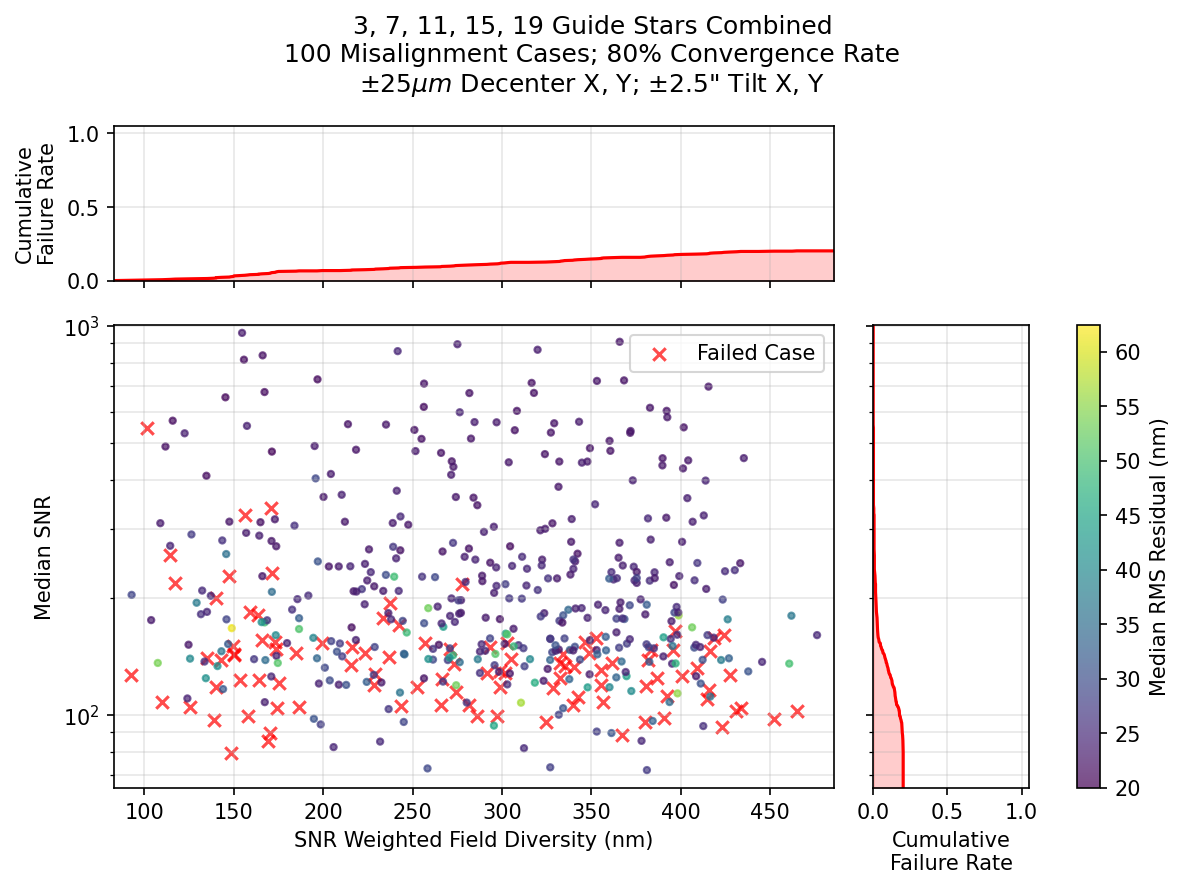

In [23]:
fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(8, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

axs['poop'].set_axis_off()

ax = axs['scatter']
ax.scatter(fails_x, fails_y, c='r', alpha=0.7, marker='x', label='Failed Case')
s = ax.scatter(xs, ys, c=cs, alpha=0.7, marker='.')
ax.set_yscale('log')
s.set_clim([cmin, cmax])
ax.set_xlabel('SNR Weighted Field Diversity (nm)')
ax.set_ylabel('Median SNR')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([ymin , ymax ])
ax.grid(which='both', alpha=0.3)
ax.legend(loc='upper right')

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual (nm)')

ax = axs['histx']
ax.plot(cdf_x, cdf_opd, color='r')
ax.fill_between(cdf_x, cdf_opd, alpha=0.2, color='r')
# ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Cumulative\nFailure Rate')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([0, 1.05])
ax.grid(which='both', alpha=0.3)

ax = axs['histy']
ax.plot(cdf_snr, cdf_y, color='r')
ax.fill_betweenx(cdf_y, cdf_snr, alpha=0.2, color='r')
ax.set_yscale('log')
# ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xticks([0, 0.5, 1])
ax.set_xlabel('Cumulative\nFailure Rate')
ax.set_ylim([ymin , ymax ])
ax.set_xlim([0, 1.05])
ax.grid(which='both', alpha=0.3)

fig.suptitle(f'3, 7, 11, 15, 19 Guide Stars Combined\n{len(data):02.0f} Misalignment Cases; {len(cs) / 500 * 100:02.0f}% Convergence Rate\n$\pm25\mu m$ Decenter X, Y; $\pm2.5$" Tilt X, Y')


In [24]:
count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

# for x, y, c in zip(median_rms_truth, weighted_sum_diversity, median_rms_residual):
#     if c < 62.5:
#         xs.append(float(x))
#         ys.append(float(y))
#         cs.append(float(c))
#     else:
#         fails_x.append(float(x))
#         fails_y.append(float(y))

for x, y, c in zip(median_rms_truth, weighted_sum_diversity, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min() * 0.9
xmax = _np.array([xs.max(), fails_x.max()]).max() * 1.02

ymin = _np.array([ys.min(), fails_y.min()]).min() * 0.9
ymax = _np.array([ys.max(), fails_y.max()]).max() * 1.05

cmin = 20
cmax = 62.5

sorted_fails_x = sorted(fails_x)
cdf_opd = [0]
cdf_x = [xmin ]
x = xmin
count = 0
while x < xmax:
    if count == len(fails_x):
        x += 10
        break
    if x + 10 < sorted_fails_x[count]:
        x += 10
        cdf_x.append(x)
        cdf_opd.append(cdf_opd[-1])
    else:
        x = sorted_fails_x[count]
        cdf_x.append(x)
        cdf_opd.append((((count + 1) / 500)))
        count += 1
cdf_x.append(xmax )
cdf_opd.append(cdf_opd[-1])
cdf_opd = _np.array(cdf_opd)
cdf_x = _np.array(cdf_x)

sorted_fails_y = _np.flip(sorted(fails_y))
cdf_snr = [0]
cdf_y = [ymax ]
y = ymax
count = 0
while y > ymin:
    if count == len(fails_y):
        y -= 10
        break
    if y - 10 > sorted_fails_y[count]:
        y -= 10
        cdf_y.append(y)
        cdf_snr.append(cdf_snr[-1])
    else:
        y = sorted_fails_y[count]
        cdf_y.append(y)
        cdf_snr.append((((count + 1) / 500)))
        count += 1
cdf_y.append(ymin )
cdf_snr.append(cdf_snr[-1])
cdf_snr = _np.array(cdf_snr)
cdf_y = _np.array(cdf_y)

Text(0.5, 0.98, '3, 7, 11, 15, 19 Guide Stars Combined\n100 Misalignment Cases; 80% Convergence Rate\n$\\pm25\\mu m$ Decenter X, Y; $\\pm2.5$" Tilt X, Y')

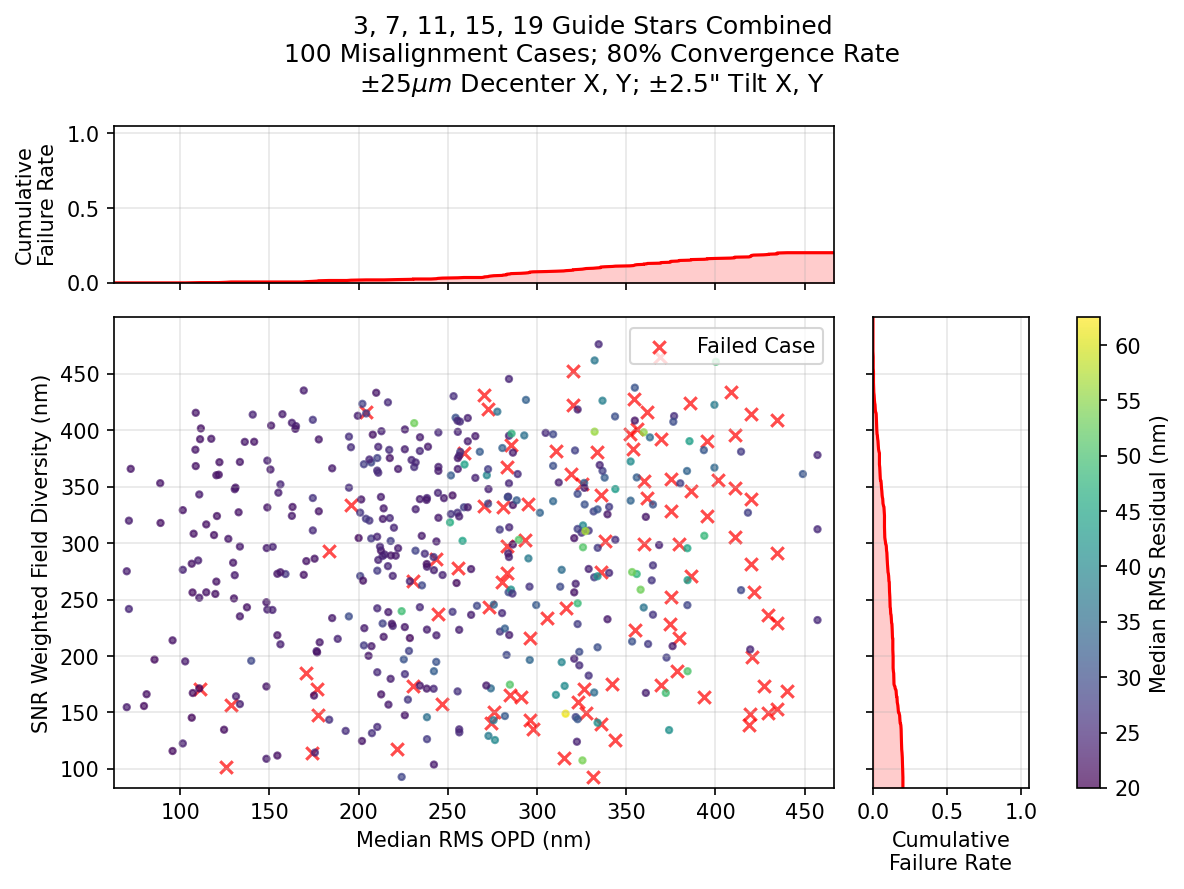

In [25]:
fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(8, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

axs['poop'].set_axis_off()

ax = axs['scatter']
ax.scatter(fails_x, fails_y, c='r', alpha=0.7, marker='x', label='Failed Case')
s = ax.scatter(xs, ys, c=cs, alpha=0.7, marker='.')
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD (nm)')
ax.set_ylabel('SNR Weighted Field Diversity (nm)')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([ymin , ymax ])
ax.grid(which='both', alpha=0.3)
ax.legend(loc='upper right')

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual (nm)')

ax = axs['histx']
ax.plot(cdf_x, cdf_opd, color='r')
ax.fill_between(cdf_x, cdf_opd, alpha=0.2, color='r')
# ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Cumulative\nFailure Rate')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([0, 1.05])
ax.grid(which='both', alpha=0.3)

ax = axs['histy']
ax.plot(cdf_snr, cdf_y, color='r')
ax.fill_betweenx(cdf_y, cdf_snr, alpha=0.2, color='r')
# ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xticks([0, 0.5, 1])
ax.set_xlabel('Cumulative\nFailure Rate')
ax.set_ylim([ymin , ymax ])
ax.set_xlim([0, 1.05])
ax.grid(which='both', alpha=0.3)

fig.suptitle(f'3, 7, 11, 15, 19 Guide Stars Combined\n{len(data):02.0f} Misalignment Cases; {len(cs) / 500 * 100:02.0f}% Convergence Rate\n$\pm25\mu m$ Decenter X, Y; $\pm2.5$" Tilt X, Y')


In [28]:
count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

# for x, y, c in zip(median_rms_truth, weighted_sum_diversity, median_rms_residual):
#     if c < 62.5:
#         xs.append(float(x))
#         ys.append(float(y))
#         cs.append(float(c))
#     else:
#         fails_x.append(float(x))
#         fails_y.append(float(y))

for x, y, c in zip(n_stars,weighted_sum_diversity, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min() * 0.9
xmax = _np.array([xs.max(), fails_x.max()]).max() * 1.02

ymin = _np.array([ys.min(), fails_y.min()]).min() * 0.9
ymax = _np.array([ys.max(), fails_y.max()]).max() * 1.05

cmin = 20
cmax = 62.5

sorted_fails_x = sorted(fails_x)
cdf_opd = [0]
cdf_x = [xmin ]
x = xmin
count = 0
while x < xmax:
    if count == len(fails_x):
        x += 10
        break
    if x + 10 < sorted_fails_x[count]:
        x += 10
        cdf_x.append(x)
        cdf_opd.append(cdf_opd[-1])
    else:
        x = sorted_fails_x[count]
        cdf_x.append(x)
        cdf_opd.append((((count + 1) / 500)))
        count += 1
cdf_x.append(xmax )
cdf_opd.append(cdf_opd[-1])
cdf_opd = _np.array(cdf_opd)
cdf_x = _np.array(cdf_x)

sorted_fails_y = _np.flip(sorted(fails_y))
cdf_snr = [0]
cdf_y = [ymax ]
y = ymax
count = 0
while y > ymin:
    if count == len(fails_y):
        y -= 10
        break
    if y - 10 > sorted_fails_y[count]:
        y -= 10
        cdf_y.append(y)
        cdf_snr.append(cdf_snr[-1])
    else:
        y = sorted_fails_y[count]
        cdf_y.append(y)
        cdf_snr.append((((count + 1) / 500)))
        count += 1
cdf_y.append(ymin )
cdf_snr.append(cdf_snr[-1])
cdf_snr = _np.array(cdf_snr)
cdf_y = _np.array(cdf_y)

Text(0.5, 0.98, '3, 7, 11, 15, 19 Guide Stars Combined\n100 Misalignment Cases; 80% Convergence Rate\n$\\pm25\\mu m$ Decenter X, Y; $\\pm2.5$" Tilt X, Y')

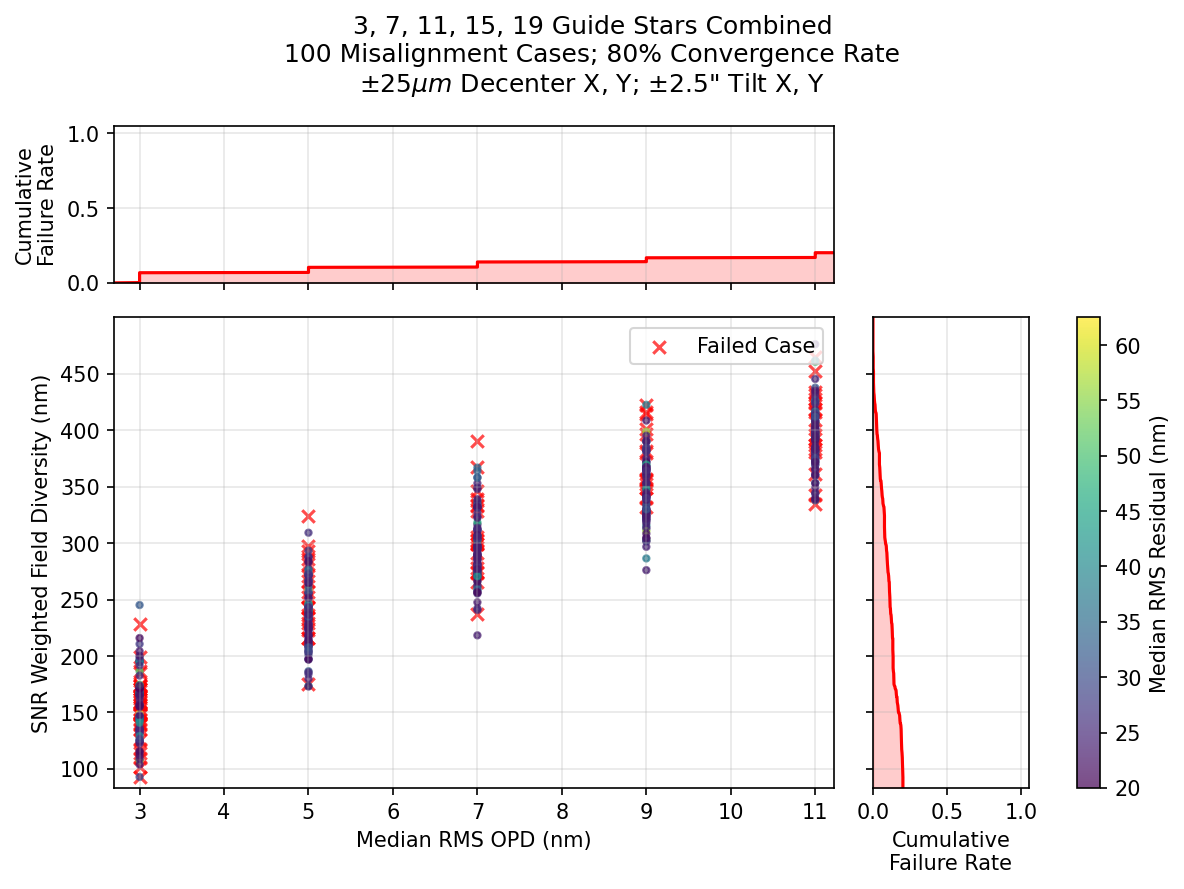

In [29]:
fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(8, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

axs['poop'].set_axis_off()

ax = axs['scatter']
ax.scatter(fails_x, fails_y, c='r', alpha=0.7, marker='x', label='Failed Case')
s = ax.scatter(xs, ys, c=cs, alpha=0.7, marker='.')
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD (nm)')
ax.set_ylabel('SNR Weighted Field Diversity (nm)')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([ymin , ymax ])
ax.grid(which='both', alpha=0.3)
ax.legend(loc='upper right')

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual (nm)')

ax = axs['histx']
ax.plot(cdf_x, cdf_opd, color='r')
ax.fill_between(cdf_x, cdf_opd, alpha=0.2, color='r')
# ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Cumulative\nFailure Rate')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([0, 1.05])
ax.grid(which='both', alpha=0.3)

ax = axs['histy']
ax.plot(cdf_snr, cdf_y, color='r')
ax.fill_betweenx(cdf_y, cdf_snr, alpha=0.2, color='r')
# ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xticks([0, 0.5, 1])
ax.set_xlabel('Cumulative\nFailure Rate')
ax.set_ylim([ymin , ymax ])
ax.set_xlim([0, 1.05])
ax.grid(which='both', alpha=0.3)

fig.suptitle(f'3, 7, 11, 15, 19 Guide Stars Combined\n{len(data):02.0f} Misalignment Cases; {len(cs) / 500 * 100:02.0f}% Convergence Rate\n$\pm25\mu m$ Decenter X, Y; $\pm2.5$" Tilt X, Y')
